## A -- Setup & Install

In [39]:
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', *pkgs, '-q'], check=False)

# Bersihin total dulu -- versi campur dari percobaan sebelumnya bikin conflict
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', '-q',
                'pydantic', 'pydantic-core', 'albumentations', 'albucore'], check=False)

# Install SATU KALI, satu perintah -- biar pip resolver pilih pydantic+pydantic-core
# yang COMPATIBLE otomatis. TIDAK ada manual pin pydantic terpisah.
pip('albumentations==1.4.24', 'timm', 'roboflow', 'torchmetrics', 'scikit-learn')

for _mod in list(sys.modules.keys()):
    if _mod.startswith(('albumentations', 'pydantic', 'albucore')):
        del sys.modules[_mod]

import os, random, time, math, json, csv, warnings, traceback, zipfile, shutil, hashlib, re
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
from pathlib import Path
from collections import defaultdict, Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

warnings.filterwarnings('ignore')

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f'torch : {torch.__version__}')
print(f'timm  : {timm.__version__}')
print(f'device: {DEVICE}')
print(f'albumentations: {A.__version__}  (HARUS 1.4.24)')
import pydantic
print(f'pydantic: {pydantic.VERSION}')
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} ({p.total_memory/1024**3:.1f}GB)')
print('Setup done.')


ERROR: Operation cancelled by user


KeyboardInterrupt: 

## B -- Config (v16: 5 sumber baru, BOXLESS_SOURCES, coin_preprocess pending) 

In [ ]:
VERSION  = 'v16'  # SATU variabel ini nentuin semua penamaan file/model di bawah.
WORK_DIR = Path('/kaggle/working')
RAW_DIR  = WORK_DIR / 'raw_sources'
DATA_DIR = WORK_DIR / f'dataset_{VERSION}'
OUT      = WORK_DIR / 'outputs'
for d in [RAW_DIR, DATA_DIR, OUT]: d.mkdir(parents=True, exist_ok=True)

random.seed(42)

IMG_SIZE = 256

MODEL_NAME    = f'Classifier_MobileNetV4_CBAM_{VERSION}_CONV'
BACKBONE_NAME = 'mobilenetv4_conv_medium.e500_r256_in1k'
# v16: backbone TIDAK diganti -- satu variabel per eksperimen, dan v16 sudah
# bawa perubahan data besar (5 source baru). Jangan gabung dengan eksperimen
# arsitektur di run yang sama.

CLASS_NAMES = [
    'Rp100_koin', 'Rp200_koin', 'Rp500_koin', 'Rp1000_koin',
    'Rp1000_kertas', 'Rp2000_kertas', 'Rp5000_kertas', 'Rp10000_kertas',
    'Rp20000_kertas', 'Rp50000_kertas', 'Rp100000_kertas',
]  # SAMA seperti v15 -- tidak menambah kelas baru. Rp50_koin (dari
   # new_deteksi_koin) TIDAK punya padanan di sini, ditangani lewat ambang
   # confidence di app, BUKAN kelas ke-12 (lihat plan bagian 3.4).
NUM_CLASSES   = len(CLASS_NAMES)
COIN_CLASSES  = {'Rp100_koin', 'Rp200_koin', 'Rp500_koin', 'Rp1000_koin'}
PAPER_CLASSES = set(CLASS_NAMES) - COIN_CLASSES
COIN_IDX      = [i for i,c in enumerate(CLASS_NAMES) if c in COIN_CLASSES]
PAPER_IDX     = [i for i,c in enumerate(CLASS_NAMES) if c in PAPER_CLASSES]
COIN_IDX_S    = set(COIN_IDX)
WEAK_PAPER    = set()
MED_PAPER     = set(PAPER_IDX) - WEAK_PAPER

CROP_MARGIN       = 0.12
JITTER_POS        = 0.05
JITTER_SCALE_LOW  = 0.85
JITTER_SCALE_HIGH = 1.15

BATCH_SIZE      = 64
NUM_WORKERS     = 2
EPOCHS_STAGE1   = 30
EPOCHS_STAGE2   = 50
PATIENCE        = 10
MIN_EPOCHS_S1   = 10
MIN_EPOCHS_S2   = 15
LR              = 3e-4
LR_S2           = 5e-5
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1
FOCAL_GAMMA     = 2.0

# v16: MIN/MAX_PER_CLASS DIPERTAHANKAN sama seperti v15 untuk sekarang.
# WAJIB baca ulang cetakan "Unique session per kelas" di Cell E setelah 5
# sumber baru masuk sebelum percaya angka ini masih pas -- sumber baru
# menambah banyak sesi koin, jadi kondisi lama (Rp500/Rp1000 koin rawan
# collapse di bawah ambang unique-session) mungkin sudah berubah.
MIN_PER_CLASS = 1200
MAX_PER_CLASS = 2400

# v16: BELUM diputuskan -- lihat plan bagian 3.1. ENABLE_COIN_PREPROCESS=True
# di v15 memakai cls_idx (LABEL GROUND TRUTH) untuk memilih preprocessing,
# yang TIDAK BISA direproduksi saat inference (app tidak tahu label sebelum
# klasifikasi). Keputusan True/False di sini menunggu angka Fase 0 (eval
# end-to-end) dan ablasi Fase 3 -- JANGAN diasumsikan aman cuma karena
# warisan dari v15.
ENABLE_COIN_PREPROCESS = True

# v16 BARU: sumber tanpa anotasi box (klasifikasi_koin) dibaca lewat jalur
# folder-per-class, bukan images/labels YOLO. Lihat Cell E.
BOXLESS_SOURCES = {'klasifikasi_koin'}

# v16 BARU: mode multi-box per sumber. BELUM DIISI -- tunggu hasil hitungan
# "distribusi jumlah-box-per-gambar" di Cell C2 untuk 4 sumber baru sebelum
# memutuskan. Default tetap 'strict' (gambar >1 box dibuang) kalau kosong.
# Contoh kalau perlu diaktifkan: SOURCE_MULTIBOX_MODE['new_koin_mvpr'] = 'largest'
SOURCE_MULTIBOX_MODE = {}

PTH_STAGE1  = OUT / f'best_stage1_{VERSION}.pth'
PTH_STAGE2  = OUT / f'best_stage2_{VERSION}.pth'
ONNX_PATH   = OUT / f'classifier_{VERSION}.onnx'
TFLITE_PATH = OUT / f'classifier_{VERSION}.tflite'
CSV_PATH    = OUT / f'results_{VERSION}.csv'
CM_PATH     = OUT / f'confusion_matrix_{VERSION}.png'
TC_PATH     = OUT / f'training_curves_{VERSION}.png'
BAR_PATH    = OUT / f'per_class_acc_{VERSION}.png'
E2E_CSV_PATH = OUT / f'e2e_eval_{VERSION}.csv'
ZIP_PATH    = OUT / f'classifier_mobilenetv4_cbam_rupiah_{VERSION}.zip'
BOX_MAP_PATH = DATA_DIR / 'box_map.json'

# -- CHANGELOG v15 -> v16 -----------------------------------------------------
# 1. 5 sumber baru ditambahkan: new_adelia_koin_kertas, new_koin_mvpr,
#    new_deteksi_koin, new_mln_w2 (ber-box), klasifikasi_koin (tanpa box,
#    jalur folder-per-class BARU).
# 2. SOURCE_LABEL_MAP sumber baru diisi MANUAL setelah inspeksi visual (Cell
#    C2/C3), TIDAK ditebak dari nama kelas -- proyek ini sudah pernah kena
#    tebakan salah (kertas_2016_2022 index4 "500rp" ternyata Rp5000_kertas).
#    Gerbang raise dipasang: notebook TIDAK BISA lanjut sebelum map terisi.
# 3. SOURCE_PRIORITY_DEDUP: 2 entri mati (kertas_valid, kertas_money_q0jko,
#    sudah di-drop total sejak v14) dibersihkan; 5 sumber baru ditambahkan.
# 4. BARU: eval end-to-end (localizer v4 -> crop -> classifier) sesudah Cell
#    L -- classifier v15 SEBELUMNYA cuma dites pakai crop dari GT box, tidak
#    pernah diukur pakai box hasil prediksi localizer yang sebenarnya
#    dialami user di HP.
# 5. BARU: diagnostik akurasi per SISI koin (angka vs pahlawan), memanfaatkan
#    index terpisah yang sudah ada di koin_detector_ai sejak dulu tapi belum
#    pernah dipakai untuk ini.

print(f'Config {MODEL_NAME} OK -- IMG_SIZE={IMG_SIZE}  ENABLE_COIN_PREPROCESS={ENABLE_COIN_PREPROCESS}')


## C -- Dataset Download (sumber lama + 5 sumber baru termasuk klasifikasi_koin)

In [ ]:
try:
    from kaggle_secrets import UserSecretsClient
    sec    = UserSecretsClient()
    RF_KEY = sec.get_secret('ROBOFLOW_API_KEY')
    print('RF key: Kaggle Secrets')
except Exception:
    RF_KEY = ''  # isi sendiri: app.roboflow.com -> Settings -> API Keys -> Private API Key
    print('RF key: hardcode fallback')

from roboflow import Roboflow
rf = Roboflow(api_key=RF_KEY)

KOIN_SOURCES = [
    ('koin_1000_tambahan', 'try3-mqzxg',      'seribu-rupiah-koin',     1),
    ('koin_1000_v3',       'try7-beyol',       'seribu-rupiah-koin3',    1),
    ('koin_fix2',          'fix2',             'uang-2016',              1),
    ('koin_detector_ai',   'ai-project-1kgr2', 'coin-detector-hkhvv',    9),
]
KERTAS_SOURCES = [
    ('kertas_2016_2022',   'fix-tmc9q',        'uang-2016-2022',         3),
    # kertas_valid & kertas_money_q0jko DIHAPUS v14 -- confirmed rusak, drop total.
    ('kertas_final_rb',    'final-12',          'final-rb',              3),
    ('kertas_indonesia',   'indonesia-rupiah-currency-dataset', 'indonesia-rupiah-detection', 3),
]

# -- BARU v16: 4 sumber ber-box (workspace/project/version diparsing langsung
# dari URL Roboflow yang dikasih user, SAMA PERSIS dengan yang dipakai localizer
# v4 -- konsisten, bukan didownload ulang dengan asumsi beda). --------------
NEW_BOX_SOURCES = [
    ('new_adelia_koin_kertas', 'coin-new',             'uang-rupiah-kertas-dan-koin-by-adelia-clarissa-zzt2j', 11),
    ('new_koin_mvpr',          'arfan-faris-pramatya',  'koin-rupiah-mvpr',                                     1),
    ('new_deteksi_koin',       'project-6ajl7',         'deteksi-koin-djjhw',                                   2),
    ('new_mln_w2',             'arbiyan-workspace',     'mln-w2-f6db3',                                         5),
]

ALL_SOURCES = KOIN_SOURCES + KERTAS_SOURCES + NEW_BOX_SOURCES
for name, ws, proj, ver in ALL_SOURCES:
    dst = str(RAW_DIR / name)
    if not os.path.isdir(dst):
        try:
            rf.workspace(ws).project(proj).version(ver).download('yolov8', location=dst)
            print(f'  Downloaded : {name}')
        except Exception as e:
            print(f'  SKIP {name}: {e}')
    else:
        print(f'  Exists     : {name}  (WARNING: cache lama -- hapus folder kalau mau force re-download)')

# -- BARU v16: klasifikasi_koin -- TANPA bounding box, format Roboflow beda
# (classification project, bukan object-detection). Format download 'folder'
# = struktur train/valid/test/<nama_kelas>/*.jpg, bukan images/+labels/.
# VERSION project belum dikonfirmasi user -- coba beberapa angka daripada
# nebak satu nomor dan diam-diam salah kalau gagal.
KLASIFIKASI_WS, KLASIFIKASI_PROJ = 'tes-qkhce', 'klasifikasi-koin-ajhnf'
klas_dst = str(RAW_DIR / 'klasifikasi_koin')
if not os.path.isdir(klas_dst):
    ok = False
    for v in range(1, 6):
        try:
            rf.workspace(KLASIFIKASI_WS).project(KLASIFIKASI_PROJ).version(v).download(
                'folder', location=klas_dst)
            print(f'  Downloaded : klasifikasi_koin (version={v}, format=folder)')
            ok = True
            break
        except Exception as e:
            continue
    if not ok:
        print('  SKIP klasifikasi_koin: gagal semua version 1-5. Cek manual '
              'nomor version project di roboflow.com/tes-qkhce/klasifikasi-koin-ajhnf')
else:
    print('  Exists     : klasifikasi_koin')


## C2 -- WAJIB: inspeksi kelas + distribusi box sumber baru sebelum Cell D

In [ ]:
import yaml

NEW_SOURCES_TO_INSPECT = [
    'new_adelia_koin_kertas', 'new_koin_mvpr', 'new_deteksi_koin', 'new_mln_w2',
]  # v16: 4 sumber baru ber-box. klasifikasi_koin diinspeksi terpisah di bawah
   # karena formatnya beda (folder-per-class, bukan images/+labels/ YOLO).

print('Cek data.yaml + distribusi jumlah-box-per-gambar -- JANGAN skip ini.')
print('Tujuan: (1) tau raw class id ASLI sebelum isi SOURCE_LABEL_MAP, (2) tau')
print('berapa banyak gambar bakal ke-reject strict-mode (>1 box per gambar) --')
print('ini menentukan apakah SOURCE_MULTIBOX_MODE perlu diaktifkan (Cell B).\n')

for src_name in NEW_SOURCES_TO_INSPECT:
    src_dir = RAW_DIR / src_name
    print(f'=== {src_name} ===')
    if not src_dir.exists():
        print('  FOLDER GAK ADA -- download gagal atau belum jalan Cell C.\n')
        continue

    yaml_path = src_dir / 'data.yaml'
    if yaml_path.exists():
        with open(yaml_path) as f:
            data = yaml.safe_load(f)
        names = data.get('names', 'TIDAK ADA field names di data.yaml')
        print(f'  raw classes (data.yaml): {names}')
    else:
        print('  data.yaml TIDAK ADA -- cek struktur folder manual.')

    n_img, box_count_dist = 0, {}
    for split in ['train', 'valid', 'test']:
        lbl_dir = src_dir / split / 'labels'
        if not lbl_dir.exists():
            continue
        for lbl_path in lbl_dir.glob('*.txt'):
            n_img += 1
            try:
                n_box = sum(1 for l in open(lbl_path).read().splitlines() if l.strip())
            except Exception:
                n_box = -1
            box_count_dist[n_box] = box_count_dist.get(n_box, 0) + 1
    print(f'  total label file: {n_img}')
    print(f'  distribusi jumlah-box-per-gambar: {dict(sorted(box_count_dist.items()))}')
    if n_img:
        multi = sum(v for k, v in box_count_dist.items() if k > 1)
        print(f'  -> {multi}/{n_img} gambar bakal ke-reject otomatis (strict mode, >1 box)')
        if multi / n_img > 0.15:
            print(f'  -> PERTIMBANGKAN SOURCE_MULTIBOX_MODE[\'{src_name}\'] = \'largest\' '
                  f'di Cell B (>15% gambar bakal hilang kalau dibiarkan strict)')
    print()

print('=' * 60)
print('=== klasifikasi_koin (format beda -- folder-per-class, no data.yaml khas YOLO) ===')
klas_dir = RAW_DIR / 'klasifikasi_koin'
if not klas_dir.exists():
    print('  FOLDER GAK ADA -- download gagal atau belum jalan Cell C.\n')
else:
    print(f'  Struktur folder (depth 3, biar keliatan asli):')
    for p in sorted(klas_dir.rglob('*')):
        depth = len(p.relative_to(klas_dir).parts)
        if depth <= 2 and (p.is_dir() or depth <= 1):
            marker = '/' if p.is_dir() else ''
            print('   ', '  ' * (depth - 1), p.name + marker)
    # hitung jumlah gambar per folder kelas (folder leaf yang berisi file gambar)
    print('\n  Jumlah gambar per folder-kelas:')
    class_counts = {}
    for d in sorted(klas_dir.rglob('*')):
        if d.is_dir():
            imgs = [f for f in d.glob('*') if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
            if imgs:
                class_counts[str(d.relative_to(klas_dir))] = len(imgs)
    for k, v in class_counts.items():
        print(f'    {k:<40}: {v}')

print('\nSETELAH lihat output di atas:')
print('1. Isi SOURCE_LABEL_MAP manual di Cell D untuk 4 sumber ber-box + klasifikasi_koin.')
print('2. Kalau ada warning ">15% gambar bakal hilang", pertimbangkan SOURCE_MULTIBOX_MODE.')
print('3. JANGAN lanjut ke Cell E sebelum map terisi bener -- gerbang raise akan menahan otomatis.')


## C3 -- WAJIB: inspeksi visual kelas RAWAN + klasifikasi_koin

In [ ]:
from IPython.display import display as ipy_display, Image as IPyImage
import yaml

# WAJIB dilihat sebelum isi Cell D -- ini kelas-kelas yang paling mungkin
# salah petakan kalau cuma mengandalkan nama (lihat plan bagian 3.3).

RAWAN_TO_CHECK = {
    'new_adelia_koin_kertas': [0, 3, 6],   # "1000" vs "1rb" vs "500" -- koin
                                            # atau kertas? pola nama nebak dari
                                            # akhiran 'rb', BELUM diverifikasi.
    'new_deteksi_koin': [0, 1, 2, 3, 5, 7], # kenapa ada 2 kelas "100" dan 2
                                            # kelas "1000"? index 5 ("50 Rupiah")
                                            # dan 7 ("Balik Koin") tanpa padanan.
}

def show_class_samples(src_name, cls_ids, n_per_class=4):
    src_dir = RAW_DIR / src_name
    yaml_path = src_dir / 'data.yaml'
    names = yaml.safe_load(open(yaml_path)).get('names', []) if yaml_path.exists() else []
    shown = {c: 0 for c in cls_ids}
    for split in ['train', 'valid', 'test']:
        img_dir = src_dir / split / 'images'
        lbl_dir = src_dir / split / 'labels'
        if not img_dir.exists():
            continue
        for lbl_path in sorted(lbl_dir.glob('*.txt')):
            lines = open(lbl_path).read().splitlines()
            if not lines:
                continue
            cid = int(lines[0].split()[0])
            if cid not in cls_ids or shown[cid] >= n_per_class:
                continue
            img_path = img_dir / (lbl_path.stem + '.jpg')
            if not img_path.exists():
                cands = list(img_dir.glob(lbl_path.stem + '.*'))
                if not cands:
                    continue
                img_path = cands[0]
            cname = names[cid] if cid < len(names) else str(cid)
            print(f'{src_name} / index {cid} ({cname}) / {img_path.name}')
            ipy_display(IPyImage(filename=str(img_path), width=220))
            shown[cid] += 1

for src_name, cls_ids in RAWAN_TO_CHECK.items():
    print('=' * 60)
    print(f'{src_name} -- cek index {cls_ids}')
    print('=' * 60)
    show_class_samples(src_name, cls_ids)

# -- klasifikasi_koin: sample per folder-kelas, buat verifikasi crop-nya
# ketat ke koin (bukan foto meja luas) -- lihat plan bagian 6. -------------
print('=' * 60)
print('klasifikasi_koin -- cek crop ketat atau tidak (menentukan bisa dipakai)')
print('=' * 60)
klas_dir = RAW_DIR / 'klasifikasi_koin'
if klas_dir.exists():
    n_per_class = 3
    shown_per_folder = {}
    for f in sorted(klas_dir.rglob('*')):
        if f.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        folder_key = str(f.parent.relative_to(klas_dir))
        if shown_per_folder.get(folder_key, 0) >= n_per_class:
            continue
        print(f'{folder_key} / {f.name}')
        ipy_display(IPyImage(filename=str(f), width=220))
        shown_per_folder[folder_key] = shown_per_folder.get(folder_key, 0) + 1
else:
    print('  folder tidak ada, skip.')

print('\nSetelah lihat semua di atas: isi SOURCE_LABEL_MAP di Cell D berdasarkan')
print('apa yang KELIHATAN, bukan berdasarkan nama kelas atau dugaan pola nama.')


## D -- SOURCE_LABEL_MAP + gerbang verifikasi + helper functions

In [ ]:
NEEDS_VERIFICATION = 'TODO_VERIFY_VISUAL'   # sentinel -- gerbang raise di bawah
                                              # menahan notebook selama nilai ini
                                              # masih ada di SOURCE_LABEL_MAP manapun.

SOURCE_LABEL_MAP = {
    'koin_1000_tambahan': {0: 3},
    'koin_1000_v3':       {0: 3},
    'kertas_2016_2022': {
        0: 8, 1: 1, 2: 5, 3: 9,
        4: None,  # lima ratus rupiah -- TERBUKTI VISUAL Rp5000_kertas, BUKAN Rp500_koin
        5: 6, 6: 7, 7: 10,
        8: 0, 9: 4, 10: 3,
    },
    'kertas_final_rb':  {0: 10, 1: 7, 2: 4, 3: 8, 4: 5, 5: 9, 6: 6},
    'koin_fix2': {
        0: 1, 1: 2, 2: 0, 3: 3,
    },
    'kertas_indonesia': {0: 4, 1: 7, 2: 10, 3: 5, 4: 8, 5: 6, 6: 9},
    'koin_detector_ai': {
        0: 3, 1: 3, 2: 0, 3: 0, 4: 1, 5: 1, 6: 2, 7: 2,
    },

    'new_adelia_koin_kertas': {
        # verifikasi visual selesai: "1000" = koin, "1rb" = kertas (dikonfirmasi
        # manual). Cocok dengan dugaan awal, 3 RAWAN diisi final di sini.
        0: 3,    # "1000" -> Rp1000_koin (VERIFIED)
        1: 10,   # "100rb"  -> Rp100000_kertas
        2: 7,    # "10rb"   -> Rp10000_kertas
        3: 4,    # "1rb" -> Rp1000_kertas (VERIFIED)
        4: 8,    # "20rb"   -> Rp20000_kertas
        5: 5,    # "2rb"    -> Rp2000_kertas
        6: 2,    # "500" -> Rp500_koin (VERIFIED, pola sama dgn 0/3 di atas)
        7: 9,    # "50rb"   -> Rp50000_kertas
        8: 6,    # "5rb"    -> Rp5000_kertas
    },

    'new_koin_mvpr': {
        0: 0, 1: 1, 2: 2,
    },

    # new_deteksi_koin DIBUANG TOTAL -- inspeksi visual nunjukin kelas "100"
    # dan "1000" (raw index 0,2 -- bukan yang "... Rupiah") tercampur koin
    # emisi pra-2010, resiko salah label kelas 100/1000 koin. Sengaja tidak
    # dimasukkan ke map, biar di-skip otomatis di Cell E ("tidak ada di
    # SOURCE_LABEL_MAP"). Jangan hidupkan lagi tanpa dataset diperbaiki.

    'new_mln_w2': {
        0: 0, 1: 1, 2: 2,
    },
}

BOXLESS_LABEL_MAP = {
    'klasifikasi_koin': {
        '100_depan':   0, '100_belakang':   0,
        '200_depan':   1, '200_belakang':   1,
        '500_depan':   2, '500_belakang':   2,
        # klasifikasi_koin cuma 100/200/500 (cek listing Cell C2) -- GAK ada
        # folder 1000_*, jangan tambahin key mati buat itu.
    },
}


def _scan_for_unverified(d, path=''):
    found = []
    for k, v in d.items():
        p = f'{path}.{k}' if path else str(k)
        if isinstance(v, dict):
            found.extend(_scan_for_unverified(v, p))
        elif v == NEEDS_VERIFICATION:
            found.append(p)
    return found

_unverified = _scan_for_unverified(SOURCE_LABEL_MAP) + _scan_for_unverified(BOXLESS_LABEL_MAP)
if _unverified:
    raise ValueError(
        f'SOURCE_LABEL_MAP / BOXLESS_LABEL_MAP masih punya {len(_unverified)} entri '
        f'NEEDS_VERIFICATION: {_unverified}. Baca output Cell C2 (distribusi kelas) '
        f'dan Cell C3 (sample gambar) dulu, baru isi nilai final di sini. '
        f'JANGAN ditebak dari nama kelas -- proyek ini sudah pernah kena tebakan '
        f'salah persis dengan pola yang sama (lihat komentar kertas_2016_2022 index4).'
    )
print('SOURCE_LABEL_MAP & BOXLESS_LABEL_MAP OK -- tidak ada entri belum diverifikasi.')

SOURCE_MULTIBOX_MODE = SOURCE_MULTIBOX_MODE if 'SOURCE_MULTIBOX_MODE' in dir() else {}

MIN_BOX_AREA_DEFAULT = 0.008
MIN_BOX_AREA_OVERRIDE = {
    'kertas_final_rb':  0.10,
}
def get_min_area(src_name):
    return MIN_BOX_AREA_OVERRIDE.get(src_name, MIN_BOX_AREA_DEFAULT)

def get_md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f: h.update(f.read())
    return h.hexdigest()

def is_pseudo_box(cx, cy, bw, bh, tol=0.02):
    return (abs(cx-.5)<tol and abs(cy-.5)<tol and
            abs(bw-1.)<tol and abs(bh-1.)<tol)

def get_single_box(lbl_path, label_map, mode='strict', min_area=0.008):
    valid = []
    try:
        with open(lbl_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) < 5: continue
                src_id = int(p[0])
                new_id = label_map.get(src_id)
                if new_id is None: continue
                cx, cy, bw, bh = map(float, p[1:5])
                valid.append((new_id, cx, cy, bw, bh))
    except Exception:
        return None, 'read_error'

    if len(valid) == 0:
        return None, 'zero_box'

    if len(valid) > 1:
        if mode == 'strict':
            return None, 'multi_box'
        elif mode == 'largest':
            valid.sort(key=lambda v: v[3]*v[4], reverse=True)
            valid = valid[:1]
            reason_tag = 'ok_recovered_largest'
        else:
            return None, 'multi_box'
    else:
        reason_tag = 'ok'

    cls_id, cx, cy, bw, bh = valid[0]
    if is_pseudo_box(cx, cy, bw, bh):
        return None, 'pseudo_box'
    if bw * bh < min_area:
        return None, 'box_too_small'
    return (cls_id, cx, cy, bw, bh), reason_tag

def session_id_v2(fname):
    stem = re.sub(r'_jpg\.rf\..*$', '', fname)
    m = re.match(r'^(.*mp4)-?\d*$', stem, re.IGNORECASE)
    if m:
        return m.group(1)
    return stem


def split_by_session_final(items, cls_name, val_frac=0.10, test_frac=0.10, min_sessions=3):
    # items: (img_path, box, src_name) -- src_name WAJIB.
    #
    # FIX v16.1: stratifikasi PER-SOURCE dulu, baru session-balancing di dalam
    # tiap source, baru digabung. Tanpa ini: source dengan sedikit sesi tapi
    # GEDE (video, mis. 2 sesi x ~500 file) bisa "menghabiskan" target train
    # lewat greedy sebelum source dengan banyak sesi tapi KECIL (foto lepas,
    # tiap file = 1 sesi) kebagian jatah train sama sekali -- akibatnya train
    # monokultur satu jenis source dan valid/test monokultur jenis lain, jadi
    # evaluasi gak pernah ngukur performa di distribusi yang sama kayak
    # training. Ini yang terjadi di Rp1000_kertas/Rp5000_kertas v16 (train
    # 100% video, valid+test 100% kertas_indonesia -- ketauan dari diagnostik
    # error, cek CHANGELOG v16.1 di Cell B). Fix: proses tiap source terpisah,
    # masing-masing dapat train/valid/test proporsional ke volume dia sendiri.
    by_source = defaultdict(list)
    for img_path, box, src_name in items:
        by_source[src_name].append((img_path, box))

    train_out, valid_out, test_out = [], [], []
    for src_name, src_items in by_source.items():
        sessions = defaultdict(list)
        for img_path, box in src_items:
            sessions[session_id_v2(img_path.name)].append((img_path, box))
        session_list = sorted(sessions.items(), key=lambda kv: len(kv[1]), reverse=True)
        n_sessions = len(session_list)
        n = len(src_items)

        if n_sessions < min_sessions:
            print(f'  WARNING {cls_name}/{src_name}: {n_sessions} session doang -- fallback frame-level.')
            shuffled = src_items.copy()
            random.shuffle(shuffled)
            n_val = max(1, round(n * val_frac))
            n_tst = max(1, round(n * test_frac))
            train_out.extend(shuffled[n_val+n_tst:])
            valid_out.extend(shuffled[:n_val])
            test_out.extend(shuffled[n_val:n_val+n_tst])
            continue

        train_frac = 1.0 - val_frac - test_frac
        targets = {'train': n * train_frac, 'valid': n * val_frac, 'test': n * test_frac}
        counts  = {'train': 0, 'valid': 0, 'test': 0}
        buckets = {'train': [], 'valid': [], 'test': []}

        biggest_session_size = len(session_list[0][1])
        for _, v in session_list:
            deficits = {k: targets[k] - counts[k] for k in targets}
            best = max(deficits, key=deficits.get)
            buckets[best].extend(v)
            counts[best] += len(v)

        dominance_ratio = biggest_session_size / n
        if dominance_ratio > 0.25:
            print(f'  WARNING {cls_name}/{src_name}: session terbesar = {biggest_session_size}/{n} '
                  f'({dominance_ratio:.1%} DALAM source ini) -- dominasi tinggi, cek manual.')

        train_out.extend(buckets['train'])
        valid_out.extend(buckets['valid'])
        test_out.extend(buckets['test'])

    return train_out, valid_out, test_out

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

print('CHECKPOINT 0: definisi fungsi selesai.')


## E -- Pool Collection + Split + Write (v16: + 5 sumber baru, jalur BOXLESS)

In [ ]:
# -- v16: cross-source session dedup SEBELUM pool collection. 2 entri mati
# (kertas_valid, kertas_money_q0jko -- sudah di-drop total sejak v14)
# dibersihkan; 4 sumber ber-box baru ditambahkan. klasifikasi_koin TIDAK
# masuk daftar ini -- dia dibaca lewat jalur folder-per-class terpisah di
# bawah, tidak mengikuti pola nama sesi video (session_id_v2 tidak relevan
# untuk foto studio lepas).
SOURCE_PRIORITY_DEDUP = [
    'kertas_final_rb', 'kertas_2016_2022', 'kertas_indonesia',
    'koin_detector_ai', 'koin_1000_v3', 'koin_1000_tambahan', 'koin_fix2',
    'new_adelia_koin_kertas', 'new_koin_mvpr', 'new_deteksi_koin', 'new_mln_w2',
]

def session_id_v2_precheck(fname):
    stem = re.sub(r'_jpg\.rf\..*$', '', fname)
    m = re.match(r'^(.*mp4)-?\d*$', stem, re.IGNORECASE)
    if m:
        return m.group(1)
    return stem

_claimed_sessions = {}
for src_name in SOURCE_PRIORITY_DEDUP:
    src_dir = RAW_DIR / src_name
    if not src_dir.exists():
        continue
    for split in ['train', 'valid', 'test']:
        img_dir = src_dir / split / 'images'
        if not img_dir.exists():
            continue
        for img_path in img_dir.glob('*'):
            sess = session_id_v2_precheck(img_path.name)
            if sess not in _claimed_sessions:
                _claimed_sessions[sess] = src_name

print(f'Cross-source session dedup: {len(_claimed_sessions)} unique session claimed.')

print('Collecting pool...')
seen_md5 = set()
pool_by_class = defaultdict(list)
stats = Counter()

for src_dir in sorted(RAW_DIR.iterdir()):
    if not src_dir.is_dir(): continue
    src_name = src_dir.name

    # -- jalur BOXLESS (klasifikasi_koin) -- folder-per-class, tidak ada
    # images/+labels/ YOLO. Box disintesis penuh-bidang (0.5,0.5,1.0,1.0).
    # is_pseudo_box() di get_single_box() JUSTRU MEMBUANG box seperti ini
    # kalau lewat jalur biasa -- makanya jalur ini SKIP is_pseudo_box() sama
    # sekali, bukan menyamarkannya. ------------------------------------
    if src_name in BOXLESS_SOURCES:
        label_map = BOXLESS_LABEL_MAP.get(src_name)
        if label_map is None:
            print(f'  SKIP {src_name}: tidak ada di BOXLESS_LABEL_MAP')
            continue
        n_added = 0
        for cls_dir in sorted(src_dir.rglob('*')):
            if not cls_dir.is_dir():
                continue
            new_id = label_map.get(cls_dir.name)
            if new_id is None:
                continue
            for img_path in sorted(cls_dir.glob('*')):
                if img_path.suffix.lower() not in IMG_EXTS:
                    continue
                h = get_md5(img_path)
                if h in seen_md5:
                    stats['duplicate'] += 1
                    continue
                seen_md5.add(h)
                # box 5-elemen: (cx,cy,w,h,margin_override). margin=0.0
                # khusus supaya tidak menambah padding 12% yang tidak
                # dialami sumber lain (box ini sudah penuh bidang).
                # src_name ikut disimpan -- FIX v16.1: dipakai
                # split_by_session_final buat stratifikasi per-source.
                pool_by_class[new_id].append((img_path, (0.5, 0.5, 1.0, 1.0, 0.0), src_name))
                n_added += 1
                stats['ok_boxless'] += 1
        print(f'  {src_name:<35} +{n_added} (boxless, full-frame box)')
        continue

    # -- jalur BIASA (ber-box YOLO) -----------------------------------------
    label_map = SOURCE_LABEL_MAP.get(src_name)
    if label_map is None:
        print(f'  SKIP {src_name}: tidak ada di SOURCE_LABEL_MAP')
        continue
    box_mode = SOURCE_MULTIBOX_MODE.get(src_name, 'strict')
    min_area = get_min_area(src_name)
    n_added, n_recovered = 0, 0
    try:
        for split in ['train', 'valid', 'test']:
            img_dir = src_dir / split / 'images'
            lbl_dir = src_dir / split / 'labels'
            if not img_dir.exists(): continue
            for img_path in sorted(img_dir.glob('*')):
                if img_path.suffix.lower() not in IMG_EXTS: continue
                lbl_path = lbl_dir / (img_path.stem + '.txt')
                if not lbl_path.exists(): continue
                _sess = session_id_v2_precheck(img_path.name)
                if _claimed_sessions.get(_sess) != src_name:
                    stats['cross_source_dup'] += 1
                    continue
                h = get_md5(img_path)
                if h in seen_md5:
                    stats['duplicate'] += 1
                    continue
                result, reason = get_single_box(lbl_path, label_map, mode=box_mode, min_area=min_area)
                stats[reason] += 1
                if result is None:
                    continue
                cls_id, cx, cy, bw, bh = result
                seen_md5.add(h)
                # src_name ikut disimpan -- FIX v16.1, sama alasan kayak di atas.
                pool_by_class[cls_id].append((img_path, (cx, cy, bw, bh), src_name))
                n_added += 1
                if reason == 'ok_recovered_largest':
                    n_recovered += 1
    except Exception as e:
        print(f'  CRASH di source {src_name}: {type(e).__name__}: {e}')
        import traceback; traceback.print_exc()
        raise

    tag = f' (recovered={n_recovered})' if n_recovered else ''
    print(f'  {src_name:<35} +{n_added}{tag}')

print('CHECKPOINT 1: pool collection selesai.')
print(f'\nStats: {dict(stats)}')
print('\nPool per class (sebelum split):')
for i, name in enumerate(CLASS_NAMES):
    n = len(pool_by_class[i])
    flag = ' <- LOW' if n < 300 else ''
    print(f'  {name:<22}: {n:>5}{flag}')

print('\nUnique session per kelas:')
for i, name in enumerate(CLASS_NAMES):
    sessions = {session_id_v2(p.name) for p, _, _ in pool_by_class[i]}
    print(f'  {name:<22}: {len(sessions):>4} session dari {len(pool_by_class[i])} file')
print('  ^ WAJIB dibaca sebelum percaya MIN/MAX_PER_CLASS (Cell B) masih pas --')
print('    kalau ada kelas koin masih di bawah ~15-20 unique session, risiko')
print('    overfit-collapse yang sama seperti v11 masih ada meski total file naik.')

print('CHECKPOINT 2: pool summary selesai, mulai split.')

SPLIT_MODE = 'session'

print(f'\nSplit 80/10/10 (SPLIT_MODE={SPLIT_MODE})...')
train_raw, valid_raw, test_raw = defaultdict(list), defaultdict(list), defaultdict(list)

def split_random_frame_level(items, val_frac=0.10, test_frac=0.10):
    # items bisa (img_path,box) atau (img_path,box,src_name) -- strip src_name
    # kalau ada, biar output selalu 2-tuple konsisten sama write_items().
    items = [(p, b) for p, b, *_ in items]
    shuffled = items.copy()
    random.shuffle(shuffled)
    n = len(shuffled)
    n_val = max(1, round(n * val_frac))
    n_tst = max(1, round(n * test_frac))
    n_trn = n - n_val - n_tst
    return shuffled[:n_trn], shuffled[n_trn:n_trn+n_val], shuffled[n_trn+n_val:]

path_to_src = {}  # dipakai buat cetak breakdown source per split di bawah
for cls_id in range(NUM_CLASSES):
    items = pool_by_class[cls_id].copy()
    for img_path, box, src_name in items:
        path_to_src[img_path] = src_name
    if SPLIT_MODE == 'random':
        n_trn, n_val, n_tst = split_random_frame_level(items)
    else:
        n_trn, n_val, n_tst = split_by_session_final(items, CLASS_NAMES[cls_id])
    train_raw[cls_id], valid_raw[cls_id], test_raw[cls_id] = n_trn, n_val, n_tst
    print(f'  {CLASS_NAMES[cls_id]:<22} n={len(items)}  train={len(n_trn)} val={len(n_val)} test={len(n_tst)}')

print('CHECKPOINT 3: split selesai.')

def get_oversample_cap(n):
    if n < 500: return 3
    elif n < 1000: return 2
    return None

print(f'\nEqualize train (MIN={MIN_PER_CLASS}, MAX={MAX_PER_CLASS})...')
train_equalized = {}
for cls_id in range(NUM_CLASSES):
    items = train_raw[cls_id].copy()
    random.shuffle(items)
    n = len(items)
    if n == 0:
        print(f'  {CLASS_NAMES[cls_id]:<22}: WARNING 0!')
        train_equalized[cls_id] = []
        continue

    if n > MAX_PER_CLASS:
        items = items[:MAX_PER_CLASS]
        print(f'  {CLASS_NAMES[cls_id]:<22}: cap        {n} -> {MAX_PER_CLASS}')
    elif n < MIN_PER_CLASS:
        factor = math.ceil(MIN_PER_CLASS / n)
        cap = get_oversample_cap(n)
        if cap is not None and factor > cap:
            print(f'  {CLASS_NAMES[cls_id]:<22}: factor capped {factor}x -> {cap}x (n={n}, hasil={n*cap}) '
                  f'<- MASIH DI BAWAH MIN_PER_CLASS={MIN_PER_CLASS}, tiered cap menang')
            factor = cap
            items = (items * factor)[:n * factor]
        else:
            items = (items * factor)[:MIN_PER_CLASS]
            print(f'  {CLASS_NAMES[cls_id]:<22}: oversample {n} -> {len(items)} ({factor}x)')
    else:
        print(f'  {CLASS_NAMES[cls_id]:<22}: as-is      {n} (dalam range {MIN_PER_CLASS}-{MAX_PER_CLASS})')
    train_equalized[cls_id] = items

print('CHECKPOINT 4: oversample selesai.')

print('\nWriting files + box_map...')
for split in ['train', 'valid', 'test']:
    for cls in CLASS_NAMES:
        d = DATA_DIR / split / cls
        if d.exists(): shutil.rmtree(str(d))
        d.mkdir(parents=True, exist_ok=True)

box_map = {'train': {}, 'valid': {}, 'test': {}}
def write_items(items, split_name, cls_id):
    cls_name = CLASS_NAMES[cls_id]
    seen_dst = set()
    for img_path, box in items:
        stem = img_path.stem; ext = img_path.suffix
        dst  = DATA_DIR / split_name / cls_name / img_path.name
        counter = 0
        while dst.name in seen_dst or dst.exists():
            counter += 1
            dst = DATA_DIR / split_name / cls_name / f'{stem}_{counter}{ext}'
        seen_dst.add(dst.name)
        shutil.copy2(img_path, dst)
        box_map[split_name][f'{cls_name}/{dst.name}'] = list(box)

for cls_id in range(NUM_CLASSES):
    write_items(train_equalized[cls_id], 'train', cls_id)
    write_items(valid_raw[cls_id],       'valid', cls_id)
    write_items(test_raw[cls_id],        'test',  cls_id)

with open(str(BOX_MAP_PATH), 'w') as f:
    json.dump(box_map, f)
print(f'box_map saved: {BOX_MAP_PATH} ({sum(len(v) for v in box_map.values())} entries)')

TRAIN_DIR, VALID_DIR, TEST_DIR = DATA_DIR/'train', DATA_DIR/'valid', DATA_DIR/'test'

total_train = sum(len(list((TRAIN_DIR/cls).glob('*'))) for cls in CLASS_NAMES)
total_valid = sum(len(list((VALID_DIR/cls).glob('*'))) for cls in CLASS_NAMES)
total_test  = sum(len(list((TEST_DIR/cls).glob('*')))  for cls in CLASS_NAMES)
print(f'\nTotal: train={total_train} valid={total_valid} test={total_test}')

print('\nLeakage check (session-based):')
for cls in CLASS_NAMES:
    train_sess = {session_id_v2(p.name) for p in (TRAIN_DIR/cls).glob('*')}
    test_sess  = {session_id_v2(p.name) for p in (TEST_DIR/cls).glob('*')}
    valid_sess = {session_id_v2(p.name) for p in (VALID_DIR/cls).glob('*')}
    leak_t, leak_v = train_sess & test_sess, train_sess & valid_sess
    status = 'OK' if not leak_t and not leak_v else f'BOCOR: test={len(leak_t)} valid={len(leak_v)}'
    print(f'  {cls:<22}: {status}')

print('\nSource composition per split (FIX v16.1 -- verifikasi stratifikasi kerja,')
print('semua source yang nyumbang ke suatu kelas HARUS muncul di ketiga split,')
print('bukan cuma nongol di train atau cuma di valid/test doang):')
for cls_id in range(NUM_CLASSES):
    cls_name = CLASS_NAMES[cls_id]
    print(f'  {cls_name}:')
    for split_name, split_items in [('train', train_raw[cls_id]),
                                      ('valid', valid_raw[cls_id]),
                                      ('test',  test_raw[cls_id])]:
        counts = Counter(path_to_src.get(p, 'UNKNOWN') for p, _ in split_items)
        breakdown = ', '.join(f'{src}={n}' for src, n in counts.most_common())
        print(f'    {split_name:<6}: {breakdown}')

print('\nCross-source duplicate session check:')
session_to_sources = defaultdict(set)
for src_dir in sorted(RAW_DIR.iterdir()):
    if not src_dir.is_dir(): continue
    src_name = src_dir.name
    if src_name in BOXLESS_SOURCES: continue
    if SOURCE_LABEL_MAP.get(src_name) is None: continue
    for split in ['train', 'valid', 'test']:
        img_dir = src_dir / split / 'images'
        if not img_dir.exists(): continue
        for img_path in img_dir.glob('*'):
            session_to_sources[session_id_v2(img_path.name)].add(src_name)

dupe_found = False
for sess, srcs in session_to_sources.items():
    if len(srcs) > 1:
        dupe_found = True
        print(f'  WARNING session "{sess}" muncul di {len(srcs)} source berbeda: {sorted(srcs)}')
if not dupe_found:
    print('  OK -- tidak ada session name yang overlap lintas source.')

print('CHECKPOINT 5 (FINAL): semua tahap selesai bersih.')

import gc
del seen_md5, pool_by_class
gc.collect()


## E2 -- EDA Lengkap (raw sample per source per class + count table)

In [ ]:
from IPython.display import display as ipy_display, Image as IPyImage

def eda_raw_samples(RAW_DIR, SOURCE_LABEL_MAP, CLASS_NAMES, n_per_combo=4, seed=42,
                     target_classes=None):
    random.seed(seed)
    for src_name, label_map in SOURCE_LABEL_MAP.items():
        src_dir = RAW_DIR / src_name
        if not src_dir.exists():
            print(f'SKIP {src_name}: folder tidak ada')
            continue
        by_cls = defaultdict(list)
        for split in ['train', 'valid', 'test']:
            img_dir = src_dir / split / 'images'
            lbl_dir = src_dir / split / 'labels'
            if not img_dir.exists():
                continue
            for img_path in img_dir.glob('*'):
                if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
                    continue
                lbl_path = lbl_dir / (img_path.stem + '.txt')
                if not lbl_path.exists():
                    continue
                try:
                    lines = [l.split() for l in open(lbl_path).read().splitlines() if l.strip()]
                except Exception:
                    continue
                for p in lines:
                    if len(p) < 5:
                        continue
                    src_id = int(p[0])
                    new_id = label_map.get(src_id)
                    if new_id is None:
                        continue
                    if target_classes is not None and new_id not in target_classes:
                        continue
                    cx, cy, bw, bh = map(float, p[1:5])
                    by_cls[new_id].append((img_path, (cx, cy, bw, bh)))
                    break
        if not by_cls:
            print(f'{src_name}: tidak ada box valid ke-mapped ke target class')
            continue
        print(f'\n=== {src_name} ===')
        n_cls = len(by_cls)
        fig, axes = plt.subplots(n_cls, n_per_combo, figsize=(3*n_per_combo, 3*n_cls))
        if n_cls == 1:
            axes = axes.reshape(1, -1)
        for row, (cid, items) in enumerate(sorted(by_cls.items())):
            random.shuffle(items)
            sample = items[:n_per_combo]
            for col in range(n_per_combo):
                ax = axes[row, col]
                if col < len(sample):
                    img_path, box = sample[col]
                    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
                    h, w = img.shape[:2]
                    cx, cy, bw, bh = box
                    x1, y1 = int((cx-bw/2)*w), int((cy-bh/2)*h)
                    x2, y2 = int((cx+bw/2)*w), int((cy+bh/2)*h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
                    ax.imshow(img)
                    if col == 0:
                        ax.set_ylabel(CLASS_NAMES[cid], fontsize=9)
                ax.set_xticks([]); ax.set_yticks([])
        plt.suptitle(f'{src_name} -- raw sample class {[CLASS_NAMES[c] for c in by_cls]} (bbox hijau, SEBELUM crop)')
        plt.tight_layout()
        out_path = OUT / f'eda_raw_{src_name}_cls500.png'
        plt.savefig(str(out_path), dpi=90, bbox_inches='tight')
        plt.close()
        print(f'  saved: {out_path}')
        ipy_display(IPyImage(str(out_path)))

eda_raw_samples(RAW_DIR, SOURCE_LABEL_MAP, CLASS_NAMES, target_classes={0})

In [ ]:
# ============================================================================
# EDA 2 -- Count table final per class, per split. train_raw/valid_raw/test_raw
# di sini PRA-oversample (angka natural asli), train_equalized itu POST-oversample
# (yang beneran dipakai training). Dua-duanya ditampilkan biar keliatan gap-nya.
# ============================================================================
print(f'{"class":<20}{"train(raw)":>12}{"valid":>8}{"test":>8}{"total":>8}')
print('-' * 56)
grand_t = grand_v = grand_te = 0
for cid, name in enumerate(CLASS_NAMES):
    nt, nv, nte = len(train_raw[cid]), len(valid_raw[cid]), len(test_raw[cid])
    grand_t += nt; grand_v += nv; grand_te += nte
    print(f'{name:<20}{nt:>12}{nv:>8}{nte:>8}{nt+nv+nte:>8}')
print('-' * 56)
print(f'{"TOTAL":<20}{grand_t:>12}{grand_v:>8}{grand_te:>8}{grand_t+grand_v+grand_te:>8}')

print(f'\n{"class":<20}{"train(final, post-oversample)":>32}')
print('-' * 52)
for cid, name in enumerate(CLASS_NAMES):
    n_final = len(train_equalized[cid])
    flag = '  <- oversampled' if n_final > len(train_raw[cid]) else ('  <- capped' if n_final < len(train_raw[cid]) else '')
    print(f'{name:<20}{n_final:>20}{flag}')


## E3 -- ORB Standalone (persis jurnal, Hough Circle + ORB) -- pembanding skripsi, tidak terhubung training utama

In [ ]:
ORB_COIN_CLASSES = ['Rp500_koin', 'Rp1000_koin']  # cuma koin, ORB gak cocok buat kertas (deformable)
ORB_MATCH_THRESHOLD = 8   # persis threshold jurnal
MAX_TEMPLATES_PER_CLASS = 150  # cap biar gak exhaustive-compare ribuan file mentah

orb_detector_hough = cv2.ORB_create(nfeatures=500)
bf_matcher_hough    = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)


def _md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f: h.update(f.read())
    return h.hexdigest()


def compute_orb_kp_des(img_path):
    img = cv2.imread(str(img_path))
    if img is None: return None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return orb_detector_hough.detectAndCompute(gray, None)


# ---------- Bangun template bank dari DATA_DIR/train (BUKAN dari model apapun) ----------
template_bank_journal = defaultdict(list)
for cls_name in ORB_COIN_CLASSES:
    cls_dir = DATA_DIR / 'train' / cls_name
    if not cls_dir.exists():
        print(f'SKIP {cls_name}: {cls_dir} belum ada -- jalanin section D dulu.'); continue
    all_files = [p for p in sorted(cls_dir.glob('*')) if p.suffix.lower() in {'.jpg','.jpeg','.png'}]
    seen_hash, candidates = set(), []
    for p in all_files:
        h = _md5_file(p)
        if h in seen_hash: continue
        seen_hash.add(h); candidates.append(p)
    random.shuffle(candidates)
    candidates = candidates[:MAX_TEMPLATES_PER_CLASS]
    n_ok = 0
    for p in candidates:
        kp, des = compute_orb_kp_des(p)
        if kp is None or des is None or len(des) < 2: continue
        template_bank_journal[cls_name].append((p, kp, des))
        n_ok += 1
    print(f'{cls_name:<15}: {n_ok} template siap (dari {len(all_files)} file, cap={MAX_TEMPLATES_PER_CLASS})')

print(f'\ntemplate_bank_journal siap -- {sum(len(v) for v in template_bank_journal.values())} template total.')
print('Ini BUKAN hasil training, cuma kumpulan crop yang udah ada di disk sejak section D.')


In [ ]:
def preprocess_for_hough(image_bgr, target_width=800):
    """Resize(w=800) -> Grayscale -> CLAHE -> Gaussian Blur(15x15). Persis jurnal."""
    h, w = image_bgr.shape[:2]
    scale = target_width / w
    resized = cv2.resize(image_bgr, (target_width, int(h * scale)))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(contrast_enhanced, (15, 15), 0)
    return resized, blurred


def detect_coins_hough(blurred_gray, param1=100, param2=40, min_radius=20, max_radius=150):
    circles = cv2.HoughCircles(blurred_gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min_radius,
                                param1=param1, param2=param2, minRadius=min_radius, maxRadius=max_radius)
    if circles is None: return []
    circles = np.round(circles[0, :]).astype(int)
    return [(x, y, r) for x, y, r in circles]


def crop_roi(image, x, y, r, margin=1.15):
    r_m = int(r * margin)
    h, w = image.shape[:2]
    x1, y1 = max(0, x - r_m), max(0, y - r_m)
    x2, y2 = min(w, x + r_m), min(h, y + r_m)
    if x2 <= x1 or y2 <= y1: return None
    return image[y1:y2, x1:x2]


def classify_coin_orb(roi_bgr, template_bank, threshold=ORB_MATCH_THRESHOLD):
    gray_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    kp, des = orb_detector_hough.detectAndCompute(gray_roi, None)
    if des is None or len(des) < 2: return 'UNKNOWN', 0
    best_cls, best_matches = 'UNKNOWN', 0
    for cls_name, templates in template_bank.items():
        for _, _, tmpl_des in templates:
            if tmpl_des is None or len(tmpl_des) < 2: continue
            try:
                matches = bf_matcher_hough.match(des, tmpl_des)
            except cv2.error:
                continue
            if len(matches) > best_matches:
                best_matches, best_cls = len(matches), cls_name
    if best_matches < threshold: return 'UNKNOWN', best_matches
    return best_cls, best_matches


def detect_and_classify_coins(image_bgr, template_bank):
    resized, blurred = preprocess_for_hough(image_bgr)
    circles = detect_coins_hough(blurred)
    results = []
    for (x, y, r) in circles:
        roi = crop_roi(resized, x, y, r)
        if roi is None: continue
        pred_class, n_matches = classify_coin_orb(roi, template_bank)
        results.append({'x': x, 'y': y, 'r': r, 'roi': roi,
                         'pred_class': pred_class, 'n_matches': n_matches})
    return results


print('Pipeline Hough+ORB siap: detect_and_classify_coins(image, template_bank_journal)')
print('Fungsi ini gak butuh training apapun -- bisa dipanggil dari sini, sebelum J/K/L jalan.')


## F -- Crop Helper (margin + jitter, letterbox)

In [40]:
def crop_and_letterbox(image, box, margin=CROP_MARGIN, jitter=False):
    '''
    image: HxWx3 RGB uint8 (gambar penuh/full-scene).
    box: (cx, cy, w, h) ATAU (cx, cy, w, h, margin_override) normalized 0-1.
         Elemen ke-5 dari boxless source (klasifikasi_koin, box penuh-bidang
         0.5,0.5,1.0,1.0 -- lihat Cell E) -- margin_override=0.0 dipakai supaya
         gak nambah padding abu 12% ke box yang udah penuh bidang.
    jitter=True -> simulasi box localizer gak presisi, WAJIB aktif training.
    Return: padded_img (IMG_SIZE x IMG_SIZE, letterbox) atau None.
    '''
    h, w = image.shape[:2]
    cx, cy, bw, bh = box[:4]
    if len(box) >= 5:
        margin = box[4]   # override dari box_map (boxless source), menang atas param default
    if jitter:
        cx = min(max(cx + random.uniform(-JITTER_POS, JITTER_POS), 0.01), 0.99)
        cy = min(max(cy + random.uniform(-JITTER_POS, JITTER_POS), 0.01), 0.99)
        bw = bw * random.uniform(JITTER_SCALE_LOW, JITTER_SCALE_HIGH)
        bh = bh * random.uniform(JITTER_SCALE_LOW, JITTER_SCALE_HIGH)
    bw_m = min(bw * (1 + 2 * margin), 1.0)
    bh_m = min(bh * (1 + 2 * margin), 1.0)
    x1 = max(0, int((cx - bw_m / 2) * w))
    y1 = max(0, int((cy - bh_m / 2) * h))
    x2 = min(w, int((cx + bw_m / 2) * w))
    y2 = min(h, int((cy + bh_m / 2) * h))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = image[y1:y2, x1:x2]
    ch, cw = crop.shape[:2]
    if ch == 0 or cw == 0:
        return None
    scale = IMG_SIZE / max(ch, cw)
    nh, nw = max(1, int(round(ch * scale))), max(1, int(round(cw * scale)))
    resized = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_LINEAR)
    padded = np.full((IMG_SIZE, IMG_SIZE, 3), 114, dtype=np.uint8)
    pad_y = (IMG_SIZE - nh) // 2
    pad_x = (IMG_SIZE - nw) // 2
    padded[pad_y:pad_y+nh, pad_x:pad_x+nw] = resized
    return padded
print('crop_and_letterbox siap. IMG_SIZE =', IMG_SIZE)


crop_and_letterbox siap. IMG_SIZE = 256


## F2 -- LAB L-channel -> CLAHE -> Adaptive Thresholding (coin_preprocess)

Rp500_koin: fallback rate = 0.0% (0/50, 0 di-skip karena gak ada box valid)
  montage -> /kaggle/working/outputs/coin_preprocess_check_Rp500_koin.png


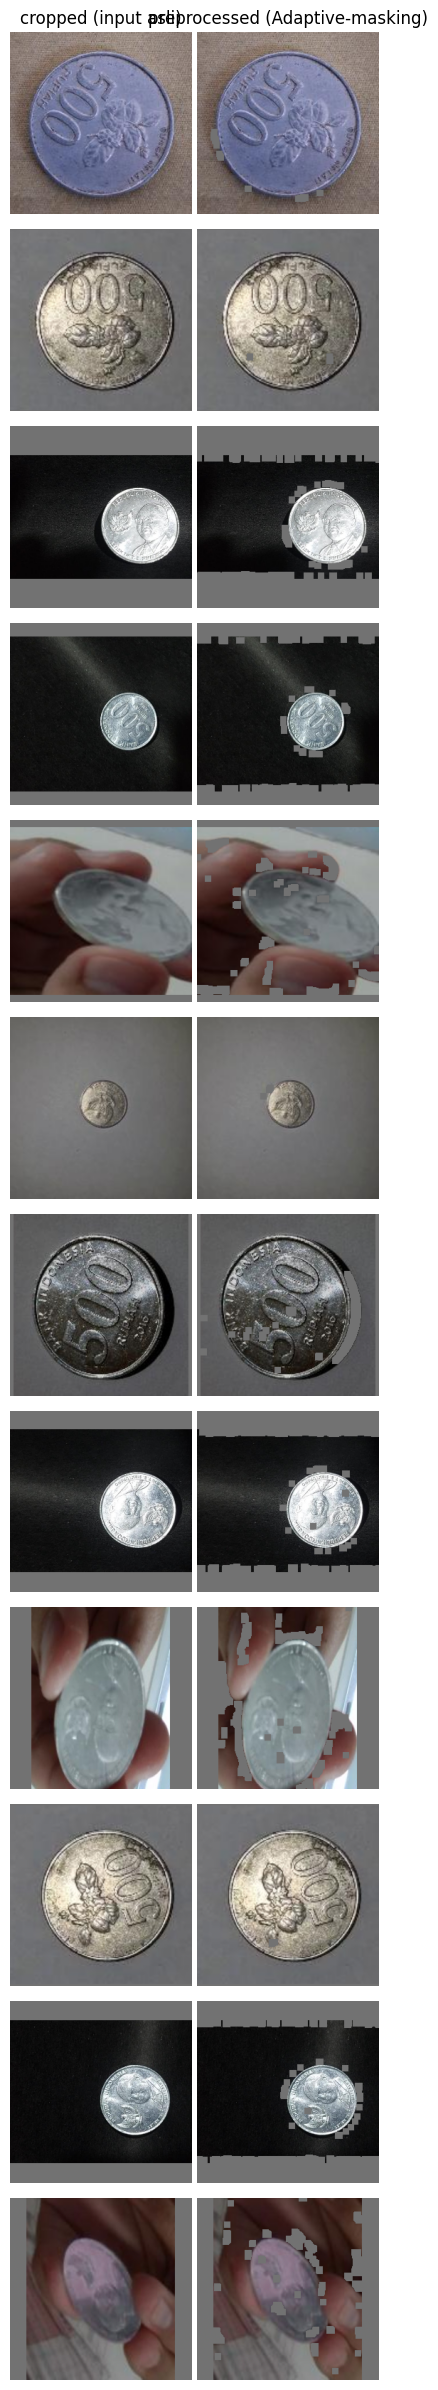

Rp1000_koin: fallback rate = 0.0% (0/50, 0 di-skip karena gak ada box valid)
  montage -> /kaggle/working/outputs/coin_preprocess_check_Rp1000_koin.png


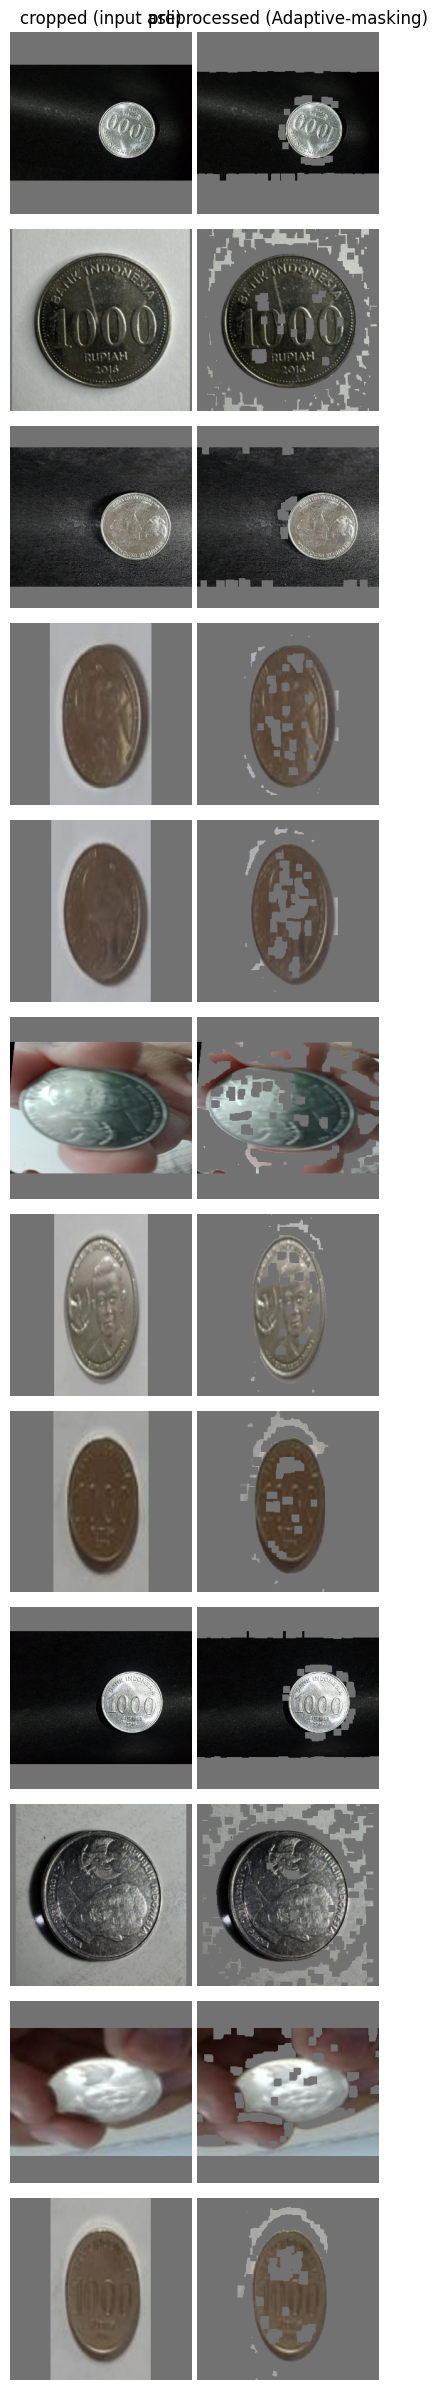

In [41]:
def coin_preprocess(image, clahe_clip=2.0, pad_value=114, pad_tol=3,
                     min_mask_ratio=0.15, max_mask_ratio=1.0,
                     adaptive_block_size=35, adaptive_C=5):
    """
    v12 -- Otsu DIBUANG, ganti Adaptive Thresholding (cv2.adaptiveThreshold,
    ADAPTIVE_THRESH_GAUSSIAN_C). Beda dari Otsu: threshold dihitung per
    neighborhood lokal (window=adaptive_block_size), bukan 1 nilai global.
    Lebih tahan gradient pencahayaan gak merata dalam 1 crop (glare koin,
    shadow separuh gambar) -- kasus yang Otsu single-threshold gagal handle.

    FIX 1 (tetap dipertahankan, independen dari algoritma threshold) --
    polarity check: adaptiveThreshold juga cuma misahin 2 kelas relatif
    terang/gelap per window, gak tau mana objek mana background. Center vs
    border mean check tetap wajib.

    FIX 2 (tetap dipertahankan) -- padding exclusion: area padding abu
    (114,114,114) dari crop_and_letterbox harus di-exclude sebelum
    thresholding, sama kayak versi Otsu, biar gak ikut ke-threshold.

    CATATAN -- adaptive_block_size WAJIB ganjil (cv2 requirement). adaptive_C
    dikurangkan dari mean lokal, makin besar C makin ketat threshold-nya jadi
    "objek". Kedua parameter ini TEBAKAN, sama kayak params Otsu dulu --
    belum ada bukti empiris angka ini optimal buat koin Rupiah, run
    validate_coin_preprocess() di bawah buat cek fallback rate riil.

    Return (None, None, None) kalau mask_ratio di luar range wajar -- caller
    WAJIB fallback ke crop original.
    """
    if adaptive_block_size % 2 == 0:
        adaptive_block_size += 1  # cv2.adaptiveThreshold crash kalau genap

    h, w = image.shape[:2]
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel = lab[:, :, 0]

    r, g, b = image[...,0].astype(int), image[...,1].astype(int), image[...,2].astype(int)
    is_padding = ((np.abs(l_channel.astype(int)-pad_value)<=pad_tol) &
                  (np.abs(r-pad_value)<=pad_tol) &
                  (np.abs(g-pad_value)<=pad_tol) &
                  (np.abs(b-pad_value)<=pad_tol))
    valid_area_mask = ~is_padding
    valid_area = valid_area_mask.sum()
    if valid_area < 0.1 * h * w:
        return None, None, None

    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    enhanced_l = clahe.apply(l_channel)

    blur = cv2.GaussianBlur(enhanced_l, (5, 5), 0)
    adaptive_mask = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        adaptive_block_size, adaptive_C)
    adaptive_mask = cv2.bitwise_and(adaptive_mask, adaptive_mask, mask=valid_area_mask.astype(np.uint8)*255)

    # FIX 1: polarity check (sama kayak versi Otsu, algoritma-independen)
    center_mean = l_channel[h//3:2*h//3, w//3:2*w//3].mean()
    border_mean = l_channel[valid_area_mask].mean() if valid_area_mask.any() else l_channel.mean()
    if center_mean < border_mean:
        adaptive_mask = cv2.bitwise_and(255 - adaptive_mask, valid_area_mask.astype(np.uint8)*255)

    kernel = np.ones((5, 5), np.uint8)
    solid_mask = cv2.morphologyEx(adaptive_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    solid_mask = cv2.bitwise_and(solid_mask, solid_mask, mask=valid_area_mask.astype(np.uint8)*255)  # reclip

    mask_ratio = (solid_mask > 0).sum() / max(valid_area, 1)
    if mask_ratio < min_mask_ratio or mask_ratio > max_mask_ratio:
        return None, None, None

    out_rgb = cv2.bitwise_and(image, image, mask=solid_mask)
    out_rgb[solid_mask == 0] = (114, 114, 114)

    return out_rgb, solid_mask, None


def validate_coin_preprocess(dataset_root, split_name, cls_names=('Rp500_koin','Rp1000_koin'),
                              n_sample=50, save_montage=True):
    with open(str(BOX_MAP_PATH)) as f:
        box_lookup = json.load(f)[split_name]

    results = {}
    for cname in cls_names:
        cls_dir = Path(dataset_root) / cname
        files = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
        random.shuffle(files)
        files = files[:n_sample]

        n_fail, n_no_box, montage = 0, 0, []
        for f in files:
            box = box_lookup.get(f'{cname}/{f.name}')   # FIX v13: class-qualified key
            if box is None:
                n_no_box += 1
                continue
            img = cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB)
            cropped = crop_and_letterbox(img, tuple(box), jitter=False)
            if cropped is None:
                n_no_box += 1
                continue
            out, mask, angle = coin_preprocess(cropped)
            if out is None:
                n_fail += 1
            elif save_montage and len(montage) < 12:
                montage.append((cropped, out))

        n_valid = len(files) - n_no_box
        fail_rate = n_fail / n_valid if n_valid else 0.0
        results[cname] = fail_rate
        print(f'{cname}: fallback rate = {fail_rate:.1%} ({n_fail}/{n_valid}, '
              f'{n_no_box} di-skip karena gak ada box valid)')

        if save_montage and montage:
            n_rows = len(montage)
            fig, axes = plt.subplots(n_rows, 2, figsize=(4, 2*n_rows), squeeze=False)
            for i, (orig, proc) in enumerate(montage):
                axes[i,0].imshow(orig); axes[i,0].axis('off')
                axes[i,1].imshow(proc); axes[i,1].axis('off')
            axes[0,0].set_title('cropped (input asli)')
            axes[0,1].set_title('preprocessed (Adaptive-masking)')
            plt.tight_layout()
            out_path = f'/kaggle/working/outputs/coin_preprocess_check_{cname}.png'
            plt.savefig(out_path, dpi=100, bbox_inches='tight')
            plt.close()
            print(f'  montage -> {out_path}')
            display(Image(out_path))
    return results

_val_results = validate_coin_preprocess(TRAIN_DIR, 'train')
for cname, fail_rate in _val_results.items():
    if fail_rate > 0.30:
        print(f'WARNING: {cname} fallback rate {fail_rate:.1%} > 30% -- '
              f'pertimbangkan ENABLE_COIN_PREPROCESS=False.')


## G -- Augmentation

In [42]:
from albumentations.pytorch import ToTensorV2
import cv2, random as _random, numpy as _np

def _reflection_overlay(image, **kwargs):
    '''
    Reflection simulation: blend scene fragment ke permukaan koin.
    BELUM diverifikasi numerik -- asumsi dari physics, wajib divalidasi.
    '''
    h, w = image.shape[:2]
    overlay = _np.zeros_like(image)
    pattern_type = _random.choice(['gradient_band', 'blob', 'streak'])

    tint = _np.array([
        _random.randint(140, 255),
        _random.randint(140, 255),
        _random.randint(140, 255),
    ], dtype=_np.uint8)

    if pattern_type == 'gradient_band':
        band_y = _random.randint(0, h)
        band_h = _random.randint(h//6, h//2)
        y1, y2 = max(0, band_y - band_h//2), min(h, band_y + band_h//2)
        overlay[y1:y2, :] = tint
    elif pattern_type == 'blob':
        cx, cy = _random.randint(0, w), _random.randint(0, h)
        radius = _random.randint(w//6, w//3)
        yy, xx = _np.ogrid[:h, :w]
        mask = (xx - cx)**2 + (yy - cy)**2 <= radius**2
        overlay[mask] = tint
    else:
        angle = _random.uniform(0, 3.14159)
        thickness = _random.randint(w//10, w//4)
        cx, cy = w//2, h//2
        dx, dy = _np.cos(angle), _np.sin(angle)
        yy, xx = _np.ogrid[:h, :w]
        dist = _np.abs((xx-cx)*dy - (yy-cy)*dx)
        overlay[dist < thickness] = tint

    overlay = cv2.GaussianBlur(overlay, (0,0), sigmaX=_random.uniform(3,10))
    alpha = _random.uniform(0.25, 0.60)
    return cv2.addWeighted(image, 1-alpha, overlay, alpha, 0)


def build_coin_aug(size):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=360, border_mode=0, value=(114,114,114), p=0.85),  # v7: koin lingkaran, no fixed orientation -> full 360
        A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.8),
        A.RandomGamma(gamma_limit=(40, 160), p=0.5),
        A.Lambda(image=_reflection_overlay, p=0.55),
        A.OneOf([
            A.RandomSunFlare(flare_roi=(0.0,0.0,1.0,1.0), angle_range=(0,1),
                num_flare_circles_range=(1,4), src_radius=int(size*0.20),
                src_color=(255,255,220), p=1.0),
            A.RandomSunFlare(flare_roi=(0.0,0.0,1.0,1.0), angle_range=(0,1),
                num_flare_circles_range=(2,5), src_radius=int(size*0.30),
                src_color=(255,255,255), p=1.0),
            A.RandomToneCurve(scale=0.3, p=1.0),
        ], p=0.65),
        A.CLAHE(clip_limit=4.0, p=0.4),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=35, p=0.5),
        A.OneOf([
            A.GaussNoise(std_range=(0.03,0.12), p=1.0),
            A.ISONoise(color_shift=(0.01,0.05), intensity=(0.1,0.3), p=1.0),
        ], p=0.45),
        A.OneOf([
            A.GaussianBlur(blur_limit=3, p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        A.CoarseDropout(num_holes_range=(1,4), hole_height_range=(15,30),
                         hole_width_range=(15,30), fill_value=114, p=0.4),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

def build_paper_strong_aug(size):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, border_mode=0, value=(114,114,114), p=0.6),
        A.Perspective(scale=(0.03,0.10), pad_val=(114,114,114), p=0.5),
        A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.20, rotate_limit=15,
                            border_mode=0, value=(114,114,114), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.40, contrast_limit=0.40, p=0.7),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=55, val_shift_limit=25, p=0.65),
        A.RandomGamma(gamma_limit=(60,140), p=0.5),
        A.CLAHE(clip_limit=4.0, p=0.3),
        A.OneOf([
            A.RandomShadow(shadow_roi=(0,0,1,1), num_shadows_limit=(1,2), shadow_dimension=4, p=1.0),
            A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=1.0),
        ], p=0.3),
        A.OneOf([
            A.GaussNoise(std_range=(0.05,0.15), p=1.0),
            A.ISONoise(color_shift=(0.01,0.05), intensity=(0.1,0.3), p=1.0),
        ], p=0.5),
        A.OneOf([
            A.MotionBlur(blur_limit=7, p=1.0),
            A.GaussianBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        A.CoarseDropout(num_holes_range=(1,4), hole_height_range=(10,30),
                         hole_width_range=(10,30), fill_value=114, p=0.4),
        A.Sharpen(alpha=(0.1,0.4), lightness=(0.8,1.2), p=0.3),
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.4),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

def build_paper_med_aug(size):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=12, border_mode=0, value=(114,114,114), p=0.5),
        A.Perspective(scale=(0.02,0.06), pad_val=(114,114,114), p=0.35),
        A.RandomBrightnessContrast(brightness_limit=0.28, contrast_limit=0.28, p=0.6),
        A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=35, val_shift_limit=18, p=0.55),
        A.OneOf([
            A.GaussNoise(std_range=(0.03,0.10), p=1.0),
            A.GaussianBlur(blur_limit=3, p=1.0),
        ], p=0.35),
        A.CoarseDropout(num_holes_range=(1,2), hole_height_range=(6,20),
                         hole_width_range=(6,20), fill_value=114, p=0.25),
        A.Sharpen(alpha=(0.1,0.35), lightness=(0.85,1.15), p=0.3),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

def build_val_aug(size):
    return A.Compose([
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

AUG_COIN   = build_coin_aug(IMG_SIZE)
AUG_STRONG = build_paper_strong_aug(IMG_SIZE)
AUG_MED    = build_paper_med_aug(IMG_SIZE)
VAL_AUG    = build_val_aug(IMG_SIZE)
print(f'Augmentation ready @ IMG_SIZE={IMG_SIZE}')


Augmentation ready @ IMG_SIZE=256


## H -- Dataset + DataLoader (v16: margin-override 5-elemen box utk BOXLESS_SOURCES)

In [43]:
with open(str(BOX_MAP_PATH)) as f:
    BOX_MAP = json.load(f)


class RupiahClassifierDataset(Dataset):
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

    def __init__(self, root_dir, split_name, augment=True):
        self.augment = augment
        self.split_name = split_name
        self.box_lookup = BOX_MAP[split_name]
        self.samples = []
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            cls_dir = Path(root_dir) / cls_name
            if not cls_dir.exists(): continue
            for img_path in sorted(cls_dir.glob('*')):
                if img_path.suffix.lower() in self.IMG_EXTS:
                    self.samples.append((img_path, cls_idx))
        print(f'  {Path(root_dir).name}: {len(self.samples)} images')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls_idx = self.samples[idx]
        img = cv2.imread(str(img_path))
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        cls_name = CLASS_NAMES[cls_idx]
        box = self.box_lookup.get(f'{cls_name}/{img_path.name}')   # FIX v13: class-qualified key
        if box is None:
            cropped = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        else:
            # v16: box bisa 4 atau 5 elemen. Elemen ke-5 (kalau ada) = margin
            # override -- dipakai khusus sumber boxless (klasifikasi_koin)
            # yang box-nya penuh bidang, supaya tidak kena CROP_MARGIN=0.12
            # default (itu akan menambah padding abu-abu yang tidak dialami
            # sumber lain, karena box-nya memang sudah penuh bidang).
            if len(box) >= 5:
                box4, margin = tuple(box[:4]), box[4]
            else:
                box4, margin = tuple(box), CROP_MARGIN
            cropped = crop_and_letterbox(img, box4, margin=margin, jitter=self.augment)
            if cropped is None:
                cropped = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # -- NEW v5: Otsu+region-growing, koin doang, guarded fallback --
        if ENABLE_COIN_PREPROCESS and cls_idx in COIN_IDX_S:
            processed, _, _ = coin_preprocess(cropped)
            if processed is not None:
                cropped = cv2.resize(processed, (IMG_SIZE, IMG_SIZE))

        if self.augment:
            if cls_idx in COIN_IDX_S:
                aug = AUG_COIN
            elif cls_idx in WEAK_PAPER:
                aug = AUG_STRONG
            else:
                aug = AUG_MED
        else:
            aug = VAL_AUG

        try:
            img_t = aug(image=cropped)['image']
        except Exception:
            img_t = VAL_AUG(image=cropped)['image']

        return img_t, torch.tensor(cls_idx, dtype=torch.long)


def make_weighted_sampler(dataset):
    class_counts = Counter(cls for _, cls in dataset.samples)
    total = sum(class_counts.values())
    weights = [total / (NUM_CLASSES * class_counts[cls])
               for _, cls in dataset.samples]
    wt = torch.tensor(weights, dtype=torch.float64)
    print(f'  WeightedSampler: {len(dataset)} samples')
    return WeightedRandomSampler(wt, num_samples=len(dataset), replacement=True)


print('Building datasets...')
train_ds = RupiahClassifierDataset(TRAIN_DIR, 'train', augment=True)
valid_ds = RupiahClassifierDataset(VALID_DIR, 'valid', augment=False)
test_ds  = RupiahClassifierDataset(TEST_DIR,  'test',  augment=False)

train_sampler = make_weighted_sampler(train_ds)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'train={len(train_loader)} valid={len(valid_loader)} test={len(test_loader)} batches')


Building datasets...
  train: 18960 images
  valid: 2401 images
  test: 2227 images
  WeightedSampler: 18960 samples
train=297 valid=38 test=35 batches


## I -- CBAM (TFLite-safe)

In [44]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=[2,3], keepdim=True)
        mx  = x.flatten(2).max(dim=2).values.view(
              x.size(0), x.size(1), 1, 1)
        return x * self.sigmoid(self.fc(avg) + self.fc(mx))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        pad = (kernel_size - 1) // 2
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=pad, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True).values
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))


_x = torch.randn(2, 64, 7, 7)
_y = CBAM(64)(_x)
assert _y.shape == _x.shape
print(f'CBAM OK: {_x.shape} -> {_y.shape}')
del _x, _y

CBAM OK: torch.Size([2, 64, 7, 7]) -> torch.Size([2, 64, 7, 7])


## J -- Model (MobileNetV4 Backbone + CBAM + Classifier Head)

In [45]:
class RupiahClassifier(nn.Module):
    '''
    Pure classifier: Backbone -> CBAM -> GAP -> Dropout -> FC -> 9 classes.
    CBAM injected setelah backbone feature map. AKTIF SEJAK STAGE 1
    (with_cbam=True dipasang dari awal training -- lihat cell J), BUKAN Stage 2.
    Docstring lama nyebut 'Stage 2' -- itu stale, kode aktualnya udah CBAM-from-start.
    TFLite-safe: tidak ada dynamic ops.
    '''
    def __init__(self, backbone_name=BACKBONE_NAME,
                 num_classes=NUM_CLASSES, pretrained=True,
                 with_cbam=False):
        super().__init__()
        self.with_cbam = with_cbam

        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            features_only=True, out_indices=(-1,))

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feats = self.backbone(dummy)
        feat_channels = feats[-1].shape[1]

        self.cbam = CBAM(feat_channels) if with_cbam else nn.Identity()
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.drop  = nn.Dropout(p=0.3)
        self.fc    = nn.Linear(feat_channels, num_classes)

        print(f'{backbone_name}: feat_channels={feat_channels}')
        print(f'  with_cbam={with_cbam}')
        total = sum(p.numel() for p in self.parameters())
        print(f'  total_params={total:,}')

    def forward(self, x):
        feats = self.backbone(x)[-1]
        feats = self.cbam(feats)
        feats = self.gap(feats)
        feats = feats.flatten(1)
        feats = self.drop(feats)
        return self.fc(feats)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print('Backbone frozen.')

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        n = sum(p.numel() for p in self.backbone.parameters())
        print(f'Backbone unfrozen: {n:,} params')


_m = RupiahClassifier(pretrained=False, with_cbam=True).eval()
with torch.no_grad():
    _out = _m(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE))
assert _out.shape == (2, NUM_CLASSES), f'output shape salah: {_out.shape}'
print(f'Model forward OK: {_out.shape}')
del _m, _out

mobilenetv4_conv_medium.e500_r256_in1k: feat_channels=960
  with_cbam=True
  total_params=7,329,021
Model forward OK: torch.Size([2, 11])


## K -- Training Stage 1 (Backbone Frozen, CBAM+Head Beradaptasi)

In [46]:
class FocalLoss(nn.Module):
    '''
    Focal Loss multi-kelas (Lin et al., 2017) -- v3b upgrade dari
    CrossEntropyLoss biasa. Menekan kontribusi sample yang sudah gampang
    (pt tinggi), fokus ke hard example yang masih sering meleset --
    relevan buat koin Rp1000 & uang kertas kondisi pencahayaan ekstrem
    yang jadi masalah mismatch di real-world.
    label_smoothing tetap didukung supaya efek LABEL_SMOOTHING lama
    (config) gak hilang saat pindah dari CrossEntropyLoss ke FocalLoss.
    '''
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets, weight=self.weight,
            label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce_loss)                 # prob kelas benar
        focal_term = (1.0 - pt) ** self.gamma
        loss = focal_term * ce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


def train_one_epoch(model, loader, optimizer, scheduler,
                    loss_fn, scaler, device):
    model.train()
    total_loss=0.0; correct=0; total=0
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            logits = model(imgs)
            loss   = loss_fn(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return {'loss': total_loss/len(loader), 'acc': correct/total}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            logits = model(imgs)
        total_loss += loss_fn(logits, labels).item()
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    acc = sum(p==l for p,l in zip(all_preds,all_labels)) / len(all_labels)

    per_class = {}
    for cls_id in range(NUM_CLASSES):
        gt_mask = [l==cls_id for l in all_labels]
        n_gt    = sum(gt_mask)
        if n_gt == 0: per_class[CLASS_NAMES[cls_id]] = 0.0; continue
        n_correct = sum(p==l for p,l,m in
                        zip(all_preds,all_labels,gt_mask) if m)
        per_class[CLASS_NAMES[cls_id]] = n_correct / n_gt

    coin_acc  = sum(per_class[CLASS_NAMES[i]] for i in COIN_IDX) / len(COIN_IDX)
    paper_acc = sum(per_class[CLASS_NAMES[i]] for i in PAPER_IDX) / len(PAPER_IDX)

    return {'loss':total_loss/len(loader), 'acc':acc,
            'per_class':per_class,
            'coin_acc':coin_acc, 'paper_acc':paper_acc,
            'preds':all_preds, 'labels':all_labels}


def print_eval(res, epoch=-1, stage=''):
    tag = f'[{stage} Ep{epoch}]' if epoch>=0 else f'[{stage}]'
    print(f'\n{tag}')
    print(f'  Acc       : {res["acc"]:.4f}')
    print(f'  Coin acc  : {res["coin_acc"]:.4f}')
    print(f'  Paper acc : {res["paper_acc"]:.4f}')
    print(f'  -- Per-class --')
    for name, acc in res['per_class'].items():
        flag = '' if acc >= 0.85 else '  <- BELOW'
        bar  = '#' * int(acc * 20)
        print(f'    {name:<22}: {acc:.4f}  |{bar:<20}|{flag}')


print('='*60)
print('STAGE 1 -- Backbone frozen, No CBAM')
print(f'  Backbone: {BACKBONE_NAME}')
print(f'  Epochs  : {EPOCHS_STAGE1}')
print('='*60)

model = RupiahClassifier(pretrained=True, with_cbam=True).to(DEVICE)
# v7 FIX: CBAM ikut ada dari Stage 1 (bukan cell K yang inject CBAM baru).
# freeze_backbone() cuma freeze backbone param -- CBAM (channel+spatial
# attention) & FC head tetap trainable, jadi CBAM beneran belajar attend
# ke pola relief/angka/gambar koin DAN kertas selama Stage 1, sebelum
# backbone dibuka di Stage 2. Versi lama: CBAM baru dibikin fresh pas
# Stage 2 mulai, bareng backbone unfreeze -- CBAM gak pernah dapet
# warmup sendiri, kontradiksi sama skema Stage A/B yang dimaksud.
model.freeze_backbone()

loss_fn_s1 = FocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING).to(DEVICE)

optimizer_s1 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY)
total_steps_s1 = EPOCHS_STAGE1 * len(train_loader)
scheduler_s1   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s1, max_lr=LR, total_steps=total_steps_s1,
    pct_start=0.1, anneal_strategy='cos')
scaler_s1 = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=='cuda'))

history_s1 = {'train_loss':[],'train_acc':[],'val_acc':[],'lr':[]}
best_acc_s1=-1.0; patience_s1=0; best_epoch_s1=0
t_start_s1 = time.time(); csv_rows = []

for epoch in range(1, EPOCHS_STAGE1+1):
    t0 = time.time()
    tr = train_one_epoch(model, train_loader, optimizer_s1,
                         scheduler_s1, loss_fn_s1, scaler_s1, DEVICE)
    val = evaluate(model, valid_loader, DEVICE)
    history_s1['train_loss'].append(tr['loss'])
    history_s1['train_acc'].append(tr['acc'])
    history_s1['val_acc'].append(val['acc'])
    history_s1['lr'].append(optimizer_s1.param_groups[0]['lr'])

    t_ep = time.time()-t0
    print(f'[S1 {epoch:03d}/{EPOCHS_STAGE1}] '
          f'loss={tr["loss"]:.4f}  train_acc={tr["acc"]:.4f}  '
          f'val_acc={val["acc"]:.4f}  coin={val["coin_acc"]:.4f}  paper={val["paper_acc"]:.4f}  t={t_ep:.0f}s')

    if val['acc'] > best_acc_s1:
        best_acc_s1=val['acc']; patience_s1=0; best_epoch_s1=epoch
        torch.save(model.state_dict(), str(PTH_STAGE1))
        print(f'  Best S1 saved (acc={best_acc_s1:.4f})')
    else:
        patience_s1 += 1
        if epoch >= MIN_EPOCHS_S1 and patience_s1 >= PATIENCE:
            print(f'\nEarly stop S1 epoch {epoch}')
            break

total_s1 = (time.time()-t_start_s1)/3600
print(f'\nStage 1 done {total_s1:.2f}h  best={best_epoch_s1} acc={best_acc_s1:.4f}')

STAGE 1 -- Backbone frozen, No CBAM
  Backbone: mobilenetv4_conv_medium.e500_r256_in1k
  Epochs  : 30


model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


mobilenetv4_conv_medium.e500_r256_in1k: feat_channels=960
  with_cbam=True
  total_params=7,329,021
Backbone frozen.


KeyboardInterrupt: 

## L -- Stage 2 (Backbone Unfrozen, CBAM Sudah Warmed-up)

In [ ]:
print('Loading Stage 1 best weights (backbone + CBAM + FC, semua sudah ada '
      'karena with_cbam=True dipasang dari Stage 1)...')
# v7 FIX: model_s2 dibikin dengan with_cbam=True juga -- arsitektur PERSIS
# sama dengan model Stage 1, jadi state_dict (termasuk bobot CBAM yang udah
# sempet warmup) load bersih strict=True. Gak ada lagi CBAM diganti fresh
# di sini kayak versi lama (itu buang semua hasil belajar CBAM di Stage 1).
model_s2 = RupiahClassifier(pretrained=False, with_cbam=True)
model_s2.load_state_dict(
    torch.load(str(PTH_STAGE1), map_location='cpu'), strict=True)

model_s2 = model_s2.to(DEVICE)
model_s2.unfreeze_backbone()

with torch.no_grad():
    _out = model_s2(torch.zeros(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE))
print(f'S2 model OK: {_out.shape}')
total_p = sum(p.numel() for p in model_s2.parameters())
print(f'Total params: {total_p:,}')

print('\n'+'='*60)
print('STAGE 2 -- Backbone unfrozen + CBAM')
print(f'  LR S2   : {LR_S2}')
print(f'  Epochs  : {EPOCHS_STAGE2}')
print('='*60)

loss_fn_s2 = FocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING).to(DEVICE)

optimizer_s2 = torch.optim.AdamW(
    model_s2.parameters(), lr=LR_S2, weight_decay=WEIGHT_DECAY)
total_steps_s2 = EPOCHS_STAGE2 * len(train_loader)
scheduler_s2   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s2, max_lr=LR_S2, total_steps=total_steps_s2,
    pct_start=0.05, anneal_strategy='cos')
scaler_s2 = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=='cuda'))

history_s2 = {'train_loss':[],'train_acc':[],'val_acc':[],'lr':[]}
best_acc_s2=-1.0; patience_s2=0; best_epoch_s2=0
t_start_s2 = time.time()

for epoch in range(1, EPOCHS_STAGE2+1):
    t0 = time.time()
    tr  = train_one_epoch(model_s2, train_loader, optimizer_s2,
                          scheduler_s2, loss_fn_s2, scaler_s2, DEVICE)
    val = evaluate(model_s2, valid_loader, DEVICE)
    history_s2['train_loss'].append(tr['loss'])
    history_s2['train_acc'].append(tr['acc'])
    history_s2['val_acc'].append(val['acc'])
    history_s2['lr'].append(optimizer_s2.param_groups[0]['lr'])

    t_ep = time.time()-t0
    print(f'[S2 {epoch:03d}/{EPOCHS_STAGE2}] '
          f'loss={tr["loss"]:.4f}  train_acc={tr["acc"]:.4f}  '
          f'val_acc={val["acc"]:.4f}  coin={val["coin_acc"]:.4f}  paper={val["paper_acc"]:.4f}  t={t_ep:.0f}s')

    csv_rows.append({'stage':2,'epoch':epoch,
                     'train_loss':tr['loss'],'train_acc':tr['acc'],
                     'val_acc':val['acc'],'coin_acc':val['coin_acc'],
                     'paper_acc':val['paper_acc']})

    if val['acc'] > best_acc_s2:
        best_acc_s2=val['acc']; patience_s2=0; best_epoch_s2=epoch
        torch.save(model_s2.state_dict(), str(PTH_STAGE2))
        print_eval(val, epoch=epoch, stage='S2-Best')
        print(f'  Best S2 saved (acc={best_acc_s2:.4f})')
    else:
        patience_s2 += 1
        if epoch >= MIN_EPOCHS_S2 and patience_s2 >= PATIENCE:
            print(f'\nEarly stop S2 epoch {epoch}')
            break

total_s2  = (time.time()-t_start_s2)/3600
total_all = total_s1 + total_s2
print(f'\nStage 2 done {total_s2:.2f}h  Total={total_all:.2f}h')
print(f'Best S2 epoch={best_epoch_s2} acc={best_acc_s2:.4f}')

with open(str(CSV_PATH),'w',newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(csv_rows[0].keys()))
    w.writeheader(); w.writerows(csv_rows)
print(f'CSV saved.')

## M -- Final Evaluate + Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from IPython.display import display as ipy_display, Image as IPyImage

print('Loading best Stage 2 model...')
final_model = RupiahClassifier(pretrained=False, with_cbam=True).to(DEVICE)
final_model.load_state_dict(
    torch.load(str(PTH_STAGE2), map_location='cpu'))
final_model.eval()

print('\n-- Final Eval (Valid) --')
val_res  = evaluate(final_model, valid_loader, DEVICE)
print_eval(val_res, stage='Final-Val')

print('\n-- Final Eval (Test) --')
test_res = evaluate(final_model, test_loader, DEVICE)
print_eval(test_res, stage='Final-Test')

n_pass = sum(1 for a in test_res['per_class'].values() if a >= 0.85)
print(f'\n{n_pass}/{NUM_CLASSES} classes capai target 0.85')

n_s1=len(history_s1['train_loss']); n_s2=len(history_s2['train_loss'])
s1_ep=list(range(1,n_s1+1))
s2_ep=list(range(n_s1+1,n_s1+n_s2+1))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle(f'Training Curves -- {MODEL_NAME}', fontweight='bold')
axes[0].plot(s1_ep, history_s1['train_loss'], 'b-', label='S1')
axes[0].plot(s2_ep, history_s2['train_loss'], 'r-', label='S2')
axes[0].set_title('Train Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(s1_ep, history_s1['val_acc'],   'b-o', markersize=3, label='S1 val')
axes[1].plot(s2_ep, history_s2['val_acc'],   'r-o', markersize=3, label='S2 val')
axes[1].axhline(0.85, color='green', linestyle='--', label='target')
axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(s1_ep, history_s1['lr'], 'b-', label='S1')
axes[2].plot(s2_ep, history_s2['lr'], 'r-', label='S2')
axes[2].set_title('LR'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(TC_PATH), dpi=120); plt.close()
ipy_display(IPyImage(TC_PATH))

cm = confusion_matrix(test_res['labels'], test_res['preds'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig2, ax2 = plt.subplots(figsize=(11,9))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title(f'Confusion Matrix -- {MODEL_NAME}')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(str(CM_PATH), dpi=120); plt.close()
ipy_display(IPyImage(CM_PATH))

bar_path = BAR_PATH  # v16 FIX: pakai path dari config (VERSION-consistent),
                     # bukan hardcode -- ini akar bug chart ke-skip dari ZIP.
fig3, ax3 = plt.subplots(figsize=(11,4))
names = CLASS_NAMES
accs  = [test_res['per_class'][n] for n in names]
colors= ['#2ecc71' if a>=0.85 else '#e74c3c' for a in accs]
bars  = ax3.bar(range(len(names)), accs, color=colors, edgecolor='black')
ax3.axhline(0.85, color='blue', linestyle='--', label='Target 0.85')
ax3.set_xticks(range(len(names)))
ax3.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
ax3.set_ylim(0,1.05); ax3.set_ylabel('Accuracy')
ax3.set_title(f'Per-class Accuracy -- Test Set ({MODEL_NAME})')
for bar, acc in zip(bars, accs):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{acc:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(bar_path), dpi=120); plt.close()
ipy_display(IPyImage(bar_path))

In [75]:
PTH_STAGE2 = Path('/kaggle/input/datasets/kevinshandoyo/classifier-v16/best_stage2_v16.pth')
assert PTH_STAGE2.exists(), f'{PTH_STAGE2} gak ketemu'

Loading best Stage 2 model...
mobilenetv4_conv_medium.e500_r256_in1k: feat_channels=960
  with_cbam=True
  total_params=7,329,021

-- Final Eval (Valid) --

[Final-Val]
  Acc       : 0.9846
  Coin acc  : 0.9685
  Paper acc : 0.9983
  -- Per-class --
    Rp100_koin            : 0.9513  |################### |
    Rp200_koin            : 0.9520  |################### |
    Rp500_koin            : 0.9894  |################### |
    Rp1000_koin           : 0.9815  |################### |
    Rp1000_kertas         : 1.0000  |####################|
    Rp2000_kertas         : 1.0000  |####################|
    Rp5000_kertas         : 0.9956  |################### |
    Rp10000_kertas        : 1.0000  |####################|
    Rp20000_kertas        : 1.0000  |####################|
    Rp50000_kertas        : 0.9926  |################### |
    Rp100000_kertas       : 1.0000  |####################|

-- Final Eval (Test) --

[Final-Test]
  Acc       : 0.9879
  Coin acc  : 0.9754
  Paper acc : 0.9989

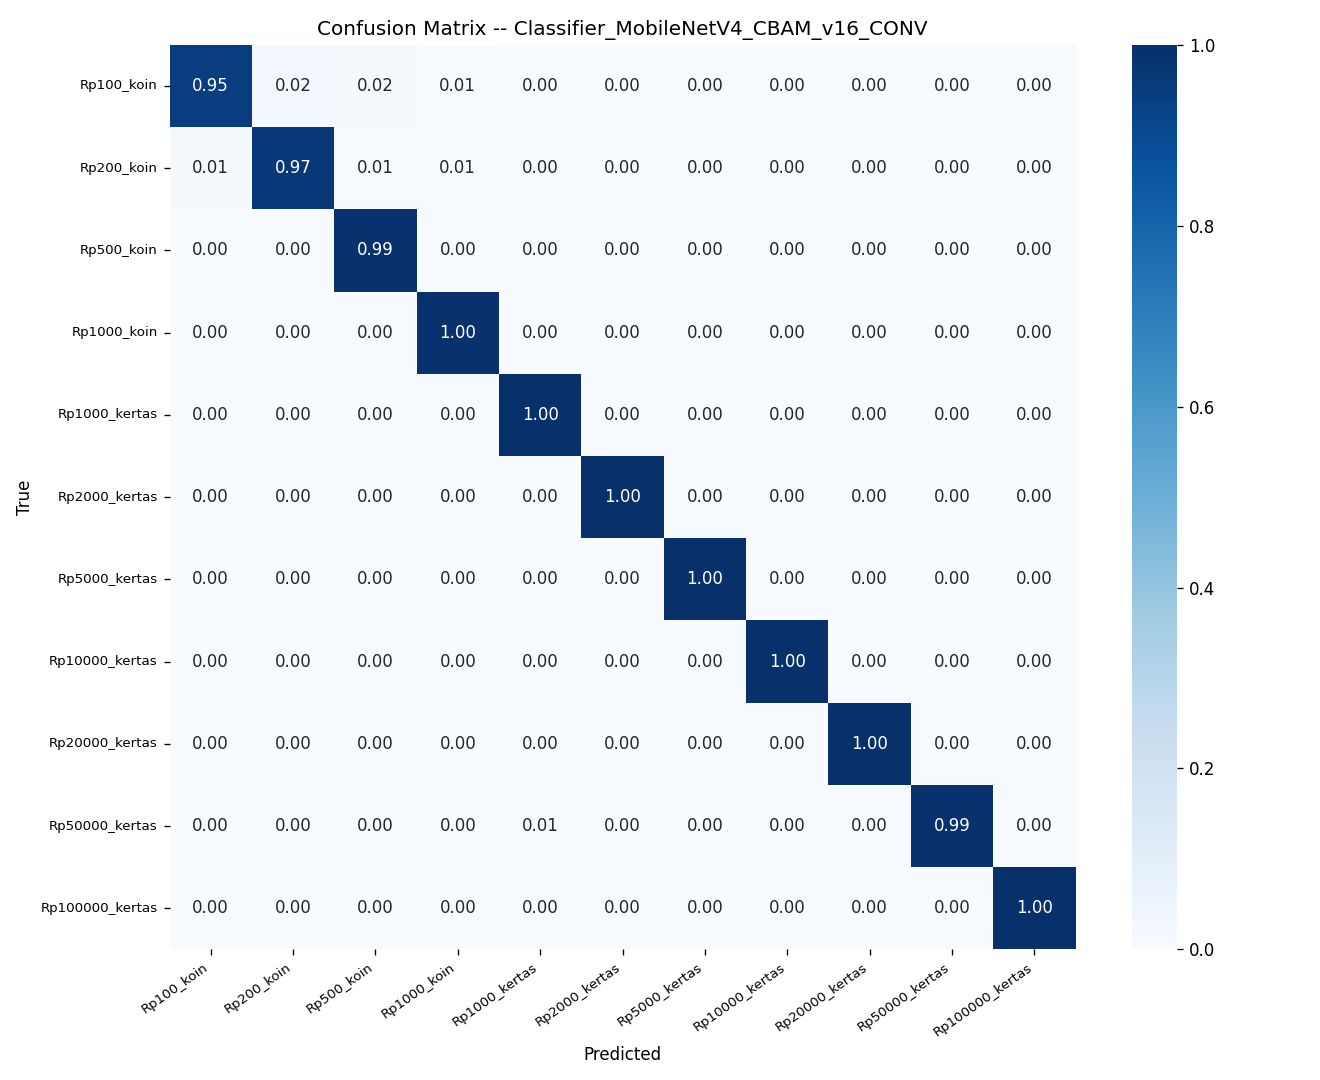

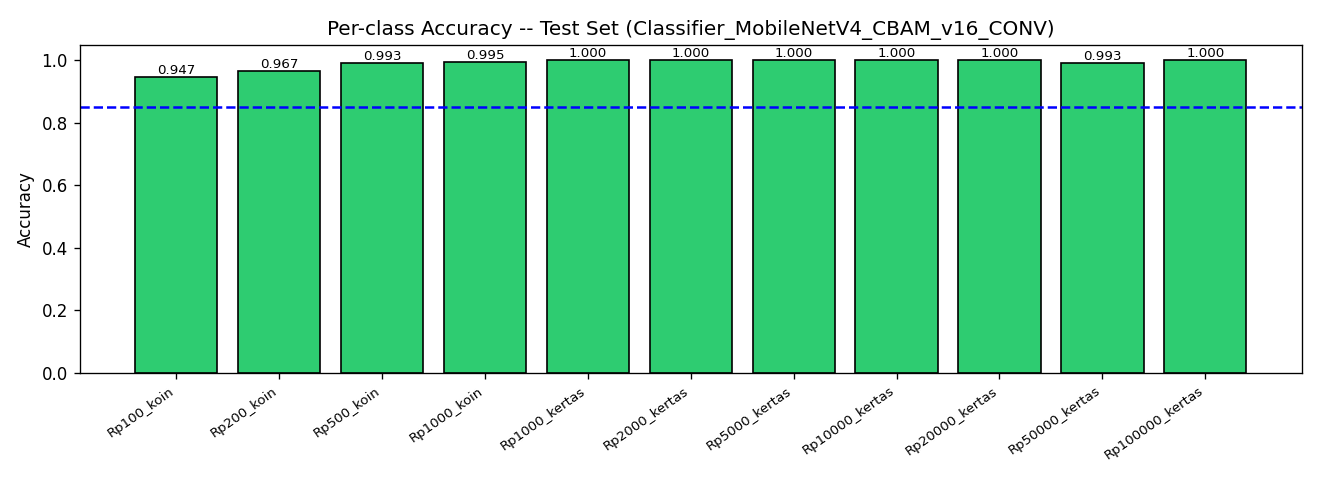

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from IPython.display import display as ipy_display, Image as IPyImage

print('Loading best Stage 2 model...')
final_model = RupiahClassifier(pretrained=False, with_cbam=True).to(DEVICE)
final_model.load_state_dict(
    torch.load(str(PTH_STAGE2), map_location='cpu'))
final_model.eval()

print('\n-- Final Eval (Valid) --')
val_res  = evaluate(final_model, valid_loader, DEVICE)
print_eval(val_res, stage='Final-Val')

print('\n-- Final Eval (Test) --')
test_res = evaluate(final_model, test_loader, DEVICE)
print_eval(test_res, stage='Final-Test')

n_pass = sum(1 for a in test_res['per_class'].values() if a >= 0.85)
print(f'\n{n_pass}/{NUM_CLASSES} classes capai target 0.85')

cm = confusion_matrix(test_res['labels'], test_res['preds'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig2, ax2 = plt.subplots(figsize=(11,9))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title(f'Confusion Matrix -- {MODEL_NAME}')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(str(CM_PATH), dpi=120); plt.close()
ipy_display(IPyImage(CM_PATH))

bar_path = BAR_PATH
fig3, ax3 = plt.subplots(figsize=(11,4))
names = CLASS_NAMES
accs  = [test_res['per_class'][n] for n in names]
colors= ['#2ecc71' if a>=0.85 else '#e74c3c' for a in accs]
bars  = ax3.bar(range(len(names)), accs, color=colors, edgecolor='black')
ax3.axhline(0.85, color='blue', linestyle='--', label='Target 0.85')
ax3.set_xticks(range(len(names)))
ax3.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
ax3.set_ylim(0,1.05); ax3.set_ylabel('Accuracy')
ax3.set_title(f'Per-class Accuracy -- Test Set ({MODEL_NAME})')
for bar, acc in zip(bars, accs):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{acc:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(bar_path), dpi=120); plt.close()
ipy_display(IPyImage(bar_path))

In [78]:
# ============================================================
# F1 SCORE -- metrik tambahan evaluasi klasifikasi.
# Dihitung dari test_res yang sudah ada (preds/labels), no retrain,
# VERSION tetap v16.
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

y_true = test_res['labels']
y_pred = test_res['preds']

f1_macro    = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)))
precision_per_class = precision_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
recall_per_class    = recall_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)

print('='*60)
print(f'F1 SCORE -- Test Set ({MODEL_NAME})')
print('='*60)
print(f'F1 macro    : {f1_macro:.4f}')
print(f'F1 weighted : {f1_weighted:.4f}')
print('\n-- Per-class (Precision / Recall / F1) --')
for i, name in enumerate(CLASS_NAMES):
    flag = '' if f1_per_class[i] >= 0.85 else '  <- BELOW'
    print(f'  {name:<22}: P={precision_per_class[i]:.4f}  R={recall_per_class[i]:.4f}  F1={f1_per_class[i]:.4f}{flag}')

coin_f1  = f1_per_class[COIN_IDX].mean()
paper_f1 = f1_per_class[PAPER_IDX].mean()
print(f'\nCoin F1 (avg)  : {coin_f1:.4f}')
print(f'Paper F1 (avg) : {paper_f1:.4f}')

print('\n-- sklearn classification_report --')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

F1 SCORE -- Test Set (Classifier_MobileNetV4_CBAM_v16_CONV)
F1 macro    : 0.9903
F1 weighted : 0.9878

-- Per-class (Precision / Recall / F1) --
  Rp100_koin            : P=0.9843  R=0.9472  F1=0.9654
  Rp200_koin            : P=0.9739  R=0.9667  F1=0.9703
  Rp500_koin            : P=0.9681  R=0.9927  F1=0.9803
  Rp1000_koin           : P=0.9712  R=0.9951  F1=0.9830
  Rp1000_kertas         : P=0.9954  R=1.0000  F1=0.9977
  Rp2000_kertas         : P=1.0000  R=1.0000  F1=1.0000
  Rp5000_kertas         : P=1.0000  R=1.0000  F1=1.0000
  Rp10000_kertas        : P=1.0000  R=1.0000  F1=1.0000
  Rp20000_kertas        : P=1.0000  R=1.0000  F1=1.0000
  Rp50000_kertas        : P=1.0000  R=0.9926  F1=0.9963
  Rp100000_kertas       : P=1.0000  R=1.0000  F1=1.0000

Coin F1 (avg)  : 0.9747
Paper F1 (avg) : 0.9991

-- sklearn classification_report --
                 precision    recall  f1-score   support

     Rp100_koin     0.9843    0.9472    0.9654       265
     Rp200_koin     0.9739    0.9667  

## N -- FASE 0: Eval End-to-End (localizer v4 -> crop -> classifier v16)

In [ ]:
# ============================================================================
# FASE 0 -- EVAL END-TO-END: localizer v4 -> crop -> classifier v16
# ============================================================================
# Classifier dites pakai crop dari GT box; di HP crop-nya datang dari
# prediksi localizer. Dua distribusi beda, dan yang kedua wajib diukur.
#
# Sel ini melaporkan 4 angka:
#   A. GT box    + preprocess pakai label GT  -> reproduksi akurasi test v16
#   B. box PREDIKSI + preprocess pakai label GT -> biaya localizer (BIAS, n dikecilkan)
#   C. box PREDIKSI + TANPA coin_preprocess     -> biaya mismatch (BIAS, n dikecilkan)
#   D. SAMA populasi kayak A, localizer-miss = SALAH -> apples-to-apples, yang app BENERAN bisa
#
# CATATAN BIAS: B dan C exclude localizer-miss dari penyebut. Miss itu gak
# acak -- terkonsentrasi di kelas susah (Rp5000/Rp10000/Rp100000_kertas), jadi
# B/C bisa keliatan LEBIH BAGUS dari A padahal itu bias seleksi, bukan
# localizer beneran lebih akurat. D itu angka yang sebanding langsung ke A --
# PAKAI D BUAT KLAIM, bukan B/C.
#
# CATATAN MISMATCH [temuan, bukan asumsi]: di Cell G,
#     if ENABLE_COIN_PREPROCESS and cls_idx in COIN_IDX_S:
# memakai cls_idx = LABEL GROUND TRUTH. Saat inference di HP, label itu justru
# yang mau diprediksi -- app TIDAK TAHU apakah crop ini koin atau kertas, jadi
# tidak ada cara memutuskan preprocess mana yang dipakai. Kolom C mengukur
# berapa mahal ketidakcocokan ini.

import numpy as np, torch, cv2, timm
from pathlib import Path
from collections import Counter, defaultdict

# -- 1. Path checkpoint localizer (Kaggle: Add Input -> dataset upload) -------
LOCALIZER_CKPT = Path('/kaggle/input/datasets/kevinshandoyo/localizer-v4/localizer_stage2.pth')  # SESUAIKAN

LOC_IMG_SIZE  = 224                              # localizer, BUKAN IMG_SIZE(=256) classifier
LOC_BACKBONE  = 'mobilenetv4_conv_medium'
LOC_USE_CBAM  = True
LOC_CONF_TH   = 0.5
LOC_NMS_TH    = 0.4

if not LOCALIZER_CKPT.exists():
    raise FileNotFoundError(
        f'{LOCALIZER_CKPT} tidak ada. Upload localizer_stage2.pth dari ZIP '
        f'localizer v4 sebagai Kaggle Dataset, lalu Add Input ke notebook ini '
        f'dan sesuaikan LOCALIZER_CKPT di atas.'
    )

# -- 2. Definisi model localizer (CBAM reuse dari Cell I classifier -- sudah
#       diverifikasi identik secara fungsional, cuma beda spasi) -------------
class RupiahLocalizerE2E(nn.Module):
    def __init__(self, backbone_name=LOC_BACKBONE, with_cbam=LOC_USE_CBAM):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=False, features_only=True, out_indices=(-2,))
        with torch.no_grad():
            feats = self.backbone(torch.zeros(1, 3, LOC_IMG_SIZE, LOC_IMG_SIZE))
        feat_channels = feats[-1].shape[1]
        self.grid_size = feats[-1].shape[-1]
        S = self.grid_size
        self.cbam = CBAM(feat_channels) if with_cbam else nn.Identity()
        self.head = nn.Sequential(
            nn.Conv2d(feat_channels, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 5, 1),
        )
        grid_y, grid_x = torch.meshgrid(
            torch.arange(S, dtype=torch.float32),
            torch.arange(S, dtype=torch.float32), indexing='ij')
        self.register_buffer('grid_x', grid_x.contiguous().clone())
        self.register_buffer('grid_y', grid_y.contiguous().clone())

    def forward(self, x):
        f = self.cbam(self.backbone(x)[-1])
        raw = self.head(f).permute(0, 2, 3, 1)
        obj = raw[..., 0:1]
        S = self.grid_size
        cx = (torch.sigmoid(raw[..., 1]) + self.grid_x) / S
        cy = (torch.sigmoid(raw[..., 2]) + self.grid_y) / S
        w  = torch.sigmoid(raw[..., 3])
        h  = torch.sigmoid(raw[..., 4])
        return torch.cat([obj, torch.stack([cx, cy, w, h], dim=-1)], dim=-1)


localizer = RupiahLocalizerE2E().to(DEVICE)
localizer.load_state_dict(torch.load(str(LOCALIZER_CKPT), map_location=DEVICE))
localizer.eval()
print(f'Localizer loaded: grid={localizer.grid_size}x{localizer.grid_size}')

# -- 3. Preprocessing localizer + pemetaan box balik ke koordinat asli -------
# Localizer dilatih pakai LongestMaxSize(224) + PadIfNeeded(center, 114).
# Box yang keluar ada di ruang koordinat LETTERBOX, bukan gambar asli.
# Harus di-unwarp dulu sebelum dipakai crop_and_letterbox(), kalau tidak crop-nya
# meleset dan salahnya tidak kelihatan (cuma jadi akurasi jelek).
_LOC_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_LOC_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def loc_letterbox(image_rgb):
    h, w = image_rgb.shape[:2]
    scale = LOC_IMG_SIZE / max(h, w)
    nh, nw = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
    resized = cv2.resize(image_rgb, (nw, nh), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((LOC_IMG_SIZE, LOC_IMG_SIZE, 3), 114, dtype=np.uint8)
    pad_y, pad_x = (LOC_IMG_SIZE - nh) // 2, (LOC_IMG_SIZE - nw) // 2
    canvas[pad_y:pad_y+nh, pad_x:pad_x+nw] = resized
    return canvas, scale, pad_x, pad_y

def loc_to_tensor(canvas):
    x = canvas.astype(np.float32) / 255.0
    x = (x - _LOC_MEAN) / _LOC_STD
    return torch.from_numpy(x.transpose(2, 0, 1))[None, ...]

def unletterbox_box(box_lb, scale, pad_x, pad_y, orig_w, orig_h):
    '''box_lb = (cx,cy,w,h) normalized di ruang letterbox 224.
    Return (cx,cy,w,h) normalized di ruang gambar ASLI.'''
    cx, cy, bw, bh = box_lb
    px, py = cx * LOC_IMG_SIZE, cy * LOC_IMG_SIZE
    pw, ph = bw * LOC_IMG_SIZE, bh * LOC_IMG_SIZE
    ox = (px - pad_x) / scale
    oy = (py - pad_y) / scale
    ow = pw / scale
    oh = ph / scale
    return (ox / orig_w, oy / orig_h, ow / orig_w, oh / orig_h)

def _iou_xywh(a, b):
    ax1, ay1, ax2, ay2 = a[0]-a[2]/2, a[1]-a[3]/2, a[0]+a[2]/2, a[1]+a[3]/2
    bx1, by1, bx2, by2 = b[0]-b[2]/2, b[1]-b[3]/2, b[0]+b[2]/2, b[1]+b[3]/2
    iw = max(min(ax2, bx2) - max(ax1, bx1), 0)
    ih = max(min(ay2, by2) - max(ay1, by1), 0)
    inter = iw * ih
    union = max(a[2]*a[3], 1e-9) + max(b[2]*b[3], 1e-9) - inter
    return inter / union if union > 0 else 0.0

@torch.no_grad()
def localize(image_rgb):
    '''Return list of (conf, cx,cy,w,h) di koordinat gambar ASLI, sudah NMS.'''
    h, w = image_rgb.shape[:2]
    canvas, scale, pad_x, pad_y = loc_letterbox(image_rgb)
    pred = localizer(loc_to_tensor(canvas).to(DEVICE))[0].cpu()
    obj = torch.sigmoid(pred[..., 0])
    S = obj.shape[0]
    cand = []
    for gj in range(S):
        for gi in range(S):
            if obj[gj, gi] >= LOC_CONF_TH:
                cand.append((obj[gj, gi].item(), *pred[gj, gi, 1:5].tolist()))
    cand.sort(key=lambda b: b[0], reverse=True)
    keep = []
    while cand:
        best = cand.pop(0)
        keep.append(best)
        cand = [c for c in cand if _iou_xywh(best[1:], c[1:]) < LOC_NMS_TH]
    return [(c, *unletterbox_box((cx, cy, bw, bh), scale, pad_x, pad_y, w, h))
            for c, cx, cy, bw, bh in keep]

# -- 4. Loop evaluasi --------------------------------------------------------
classifier = RupiahClassifier(num_classes=NUM_CLASSES, with_cbam=True).to(DEVICE)
classifier.load_state_dict(torch.load(str(PTH_STAGE2), map_location=DEVICE))
classifier.eval()

@torch.no_grad()
def classify_crop(crop_rgb, apply_coin_preprocess):
    if apply_coin_preprocess:
        processed, _, _ = coin_preprocess(crop_rgb)
        if processed is not None:
            crop_rgb = cv2.resize(processed, (IMG_SIZE, IMG_SIZE))
    t = VAL_AUG(image=crop_rgb)['image'].unsqueeze(0).to(DEVICE)
    return classifier(t).argmax(1).item()

box_lookup_test = BOX_MAP['test']
n_A = n_B = n_C = 0
ok_A = ok_B = ok_C = 0
n_missed = 0
missed_per_class = Counter()
iou_pred_vs_gt = []
# D -- populasi SAMA kayak A (semua gambar yang punya GT box), localizer gagal
# deteksi dihitung SALAH (bukan didrop). Fix bias seleksi: B/C cuma ngitung
# di antara gambar yang localizer BERHASIL deteksi, dan yang gagal itu gak
# acak -- terkonsentrasi di kelas susah. D pakai TANPA coin_preprocess
# (kondisi app beneran).
n_D = 0
ok_D = 0

for img_path, cls_idx in test_ds.samples:
    cls_name = CLASS_NAMES[cls_idx]
    gt_box = box_lookup_test.get(f'{cls_name}/{img_path.name}')
    if gt_box is None:
        continue
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    is_coin = cls_idx in COIN_IDX_S

    # A -- GT box, preprocess pakai label GT (kondisi training/test)
    crop_gt = crop_and_letterbox(img, tuple(gt_box), jitter=False)
    if crop_gt is not None:
        n_A += 1
        ok_A += int(classify_crop(crop_gt, ENABLE_COIN_PREPROCESS and is_coin) == cls_idx)

    # B, C, D -- box prediksi localizer
    dets = localize(img)
    n_D += 1  # D: masuk penyebut selama ada GT box, apapun hasil localizer
    if not dets:
        n_missed += 1
        missed_per_class[cls_name] += 1
        continue  # ok_D tidak nambah -- gagal deteksi = SALAH di D
    conf, pcx, pcy, pw, ph = max(dets, key=lambda d: d[0])
    iou_pred_vs_gt.append(_iou_xywh((pcx, pcy, pw, ph), tuple(gt_box)))

    crop_pred = crop_and_letterbox(img, (pcx, pcy, pw, ph), jitter=False)
    if crop_pred is None:
        continue  # ok_D tidak nambah -- crop gagal = SALAH di D juga
    n_B += 1
    ok_B += int(classify_crop(crop_pred, ENABLE_COIN_PREPROCESS and is_coin) == cls_idx)
    n_C += 1
    c_correct = int(classify_crop(crop_pred, False) == cls_idx)
    ok_C += c_correct
    ok_D += c_correct  # D pakai hasil sama kayak C, penyebutnya = n_A (semua gambar)

print('=' * 62)
print('EVAL END-TO-END -- localizer v4 + classifier', VERSION)
print('=' * 62)
print(f'A. GT box    + preprocess by GT label : {ok_A}/{n_A} = {ok_A/max(n_A,1):.4f}')
print(f'B. PRED box  + preprocess by GT label : {ok_B}/{n_B} = {ok_B/max(n_B,1):.4f}   (n dikecilkan, exclude localizer-miss)')
print(f'C. PRED box  + TANPA coin_preprocess  : {ok_C}/{n_C} = {ok_C/max(n_C,1):.4f}   (n dikecilkan, exclude localizer-miss)')
print(f'D. SAMA populasi kayak A, localizer-miss = SALAH : {ok_D}/{n_D} = {ok_D/max(n_D,1):.4f}   <- yang app BENERAN bisa')
print()
print('CATATAN: B dan C excludes localizer-miss dari penyebut -- kalau miss-nya')
print('gak acak (terkonsentrasi di kelas tertentu), B/C bisa keliatan lebih')
print('bagus dari A padahal itu bias seleksi, bukan localizer beneran lebih')
print('akurat. D itu angka yang sebanding langsung ke A -- pakai D buat klaim.')
print()
print(f'Localizer gagal deteksi total : {n_missed} gambar')
if missed_per_class:
    print('  per kelas:', dict(missed_per_class.most_common()))
if iou_pred_vs_gt:
    print(f'Mean IoU box prediksi vs GT   : {np.mean(iou_pred_vs_gt):.4f}')
print()
print(f'Biaya box tidak sempurna   (A -> B, BIAS, n beda)    : {(ok_A/max(n_A,1)) - (ok_B/max(n_B,1)):+.4f}')
print(f'Biaya mismatch preprocess  (B -> C, BIAS, n sama)    : {(ok_B/max(n_B,1)) - (ok_C/max(n_C,1)):+.4f}')
print(f'Biaya localizer end-to-end (A -> D, APPLES-TO-APPLES): {(ok_A/max(n_A,1)) - (ok_D/max(n_D,1)):+.4f}')
print()
print('CATATAN LEAKAGE [penting sebelum angka ini masuk laporan]: gambar test')
print('classifier bisa saja ikut dipakai saat TRAINING localizer -- keduanya')
print('menarik dari kumpulan sumber Roboflow yang sama dengan split terpisah.')
print('Kalau iya, angka B/C/D di atas terlalu optimistis. Untuk angka yang bersih,')
print('saring dulu ke gambar yang TIDAK ada di train/val localizer (cocokkan')
print('md5 -- nama file dataset localizer memang md5[:16] gambar aslinya). BELUM')
print('DIKERJAKAN -- masih TODO, jangan pakai angka ini di laporan final tanpa ini.')

with open(str(E2E_CSV_PATH), 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['metric', 'value'])
    w.writerow(['A_gt_box_gt_preprocess',   ok_A/max(n_A,1)])
    w.writerow(['B_pred_box_gt_preprocess', ok_B/max(n_B,1)])
    w.writerow(['C_pred_box_no_preprocess', ok_C/max(n_C,1)])
    w.writerow(['D_apples_to_apples',       ok_D/max(n_D,1)])
    w.writerow(['n_localizer_missed',       n_missed])
    w.writerow(['mean_iou_pred_vs_gt',      float(np.mean(iou_pred_vs_gt)) if iou_pred_vs_gt else 0.0])
print(f'\nE2E CSV saved: {E2E_CSV_PATH}')


## O -- DIAGNOSTIK BARU v16: akurasi per sisi koin (angka vs pahlawan)

In [ ]:
# ============================================================================
# DIAGNOSTIK BARU v16 -- akurasi per SISI koin (angka vs pahlawan)
# ============================================================================
# koin_detector_ai sudah memisahkan sisi angka & pahlawan di raw index terpisah
# (0,2,4,6 = angka; 1,3,5,7 = pahlawan -- lihat SOURCE_LABEL_MAP di Cell D),
# tapi keduanya di-collapse ke nominal yang sama saat training. Informasi sisi
# itu belum pernah dipakai untuk mengukur apa pun.
#
# Hipotesis [belum terbukti, plan bagian 3.6]: konfusi Rp500 vs Rp1000 yang
# menghantui v11-v13 terkonsentrasi di sisi pahlawan (butuh detail halus),
# bukan tersebar merata dengan sisi angka (gampang dibedakan).
#
# Kalau terbukti: solusinya naikkan resolusi input atau tangani di app, BUKAN
# menambah data. Kalau tidak terbukti: hipotesis tercoret, berhenti dikejar.

# Komentar asli SOURCE_LABEL_MAP (Cell D):
#   0: 3, 1: 3,   # 1000_angka, 1000_pahlawan -> Rp1000_koin
#   2: 0, 3: 0,   # 100_angka, 100_pahlawan   -> Rp100_koin
#   4: 1, 5: 1,   # 200_angka, 200_pahlawan   -> Rp200_koin
#   6: 2, 7: 2,   # 500_angka, 500_pahlawan   -> Rp500_koin
# genap = angka, ganjil = pahlawan -- KONSISTEN untuk semua 4 pasang, sesuai
# nama asli source (bukan tebakan genap/ganjil, dibaca dari komentar Cell D).
RAW_SIDE_MAP = {'koin_detector_ai': {i: ('angka' if i % 2 == 0 else 'pahlawan')
                                     for i in range(8)}}

# 1. Bangun lookup nama-file -> sisi, langsung dari label RAW (sebelum
#    remap/rename ke DATA_DIR), supaya tidak bergantung pada box_map yang
#    tidak menyimpan info sisi ini.
file_to_side = {}
for src_name, side_map in RAW_SIDE_MAP.items():
    src_dir = RAW_DIR / src_name
    if not src_dir.exists():
        continue
    for split in ['train', 'valid', 'test']:
        lbl_dir = src_dir / split / 'labels'
        if not lbl_dir.exists():
            continue
        for lbl_path in lbl_dir.glob('*.txt'):
            lines = open(lbl_path).read().splitlines()
            if not lines:
                continue
            raw_id = int(lines[0].split()[0])
            side = side_map.get(raw_id)
            if side is None:
                continue
            img_dir = lbl_dir.parent / 'images'
            for ext in ('.jpg', '.jpeg', '.png'):
                cand = img_dir / (lbl_path.stem + ext)
                if cand.exists():
                    file_to_side[cand.name] = side
                    break

print(f'file_to_side terisi: {len(file_to_side)} entri dari koin_detector_ai')

# 2. Evaluasi ulang test set, pecah per sisi (hanya untuk gambar yang
#    berasal dari koin_detector_ai -- sumber lain tidak dianotasi per sisi).
final_model.eval()
correct_by_side = defaultdict(int)
total_by_side = defaultdict(int)
confusion_by_side = defaultdict(Counter)   # side -> Counter[(true,pred)]

with torch.no_grad():
    for img_path, cls_idx in test_ds.samples:
        side = file_to_side.get(img_path.name)
        if side is None:
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cls_name = CLASS_NAMES[cls_idx]
        box = BOX_MAP['test'].get(f'{cls_name}/{img_path.name}')
        if box is None:
            cropped = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        else:
            cropped = crop_and_letterbox(img, tuple(box[:4]), jitter=False)
            if cropped is None:
                cropped = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        if ENABLE_COIN_PREPROCESS and cls_idx in COIN_IDX_S:
            processed, _, _ = coin_preprocess(cropped)
            if processed is not None:
                cropped = cv2.resize(processed, (IMG_SIZE, IMG_SIZE))
        t = VAL_AUG(image=cropped)['image'].unsqueeze(0).to(DEVICE)
        pred = final_model(t).argmax(1).item()

        total_by_side[side] += 1
        correct_by_side[side] += int(pred == cls_idx)
        confusion_by_side[side][(CLASS_NAMES[cls_idx], CLASS_NAMES[pred])] += 1

print('\n' + '=' * 60)
print('AKURASI PER SISI KOIN (koin_detector_ai saja)')
print('=' * 60)
for side in ['angka', 'pahlawan']:
    n = total_by_side[side]
    if n == 0:
        print(f'  {side:<10}: tidak ada sample di test set')
        continue
    acc = correct_by_side[side] / n
    print(f'  {side:<10}: {correct_by_side[side]}/{n} = {acc:.4f}')

print('\nTop kesalahan per sisi (true -> pred, count):')
for side in ['angka', 'pahlawan']:
    print(f'  -- {side} --')
    errs = {k: v for k, v in confusion_by_side[side].items() if k[0] != k[1]}
    for (t, p), c in sorted(errs.items(), key=lambda x: -x[1])[:5]:
        print(f'    {t} -> {p}: {c}')

acc_angka = correct_by_side['angka'] / max(total_by_side['angka'], 1)
acc_pahlawan = correct_by_side['pahlawan'] / max(total_by_side['pahlawan'], 1)
gap = acc_angka - acc_pahlawan
print(f'\nSelisih akurasi angka - pahlawan: {gap:+.4f}')
if gap > 0.05:
    print('-> Mendukung hipotesis: sisi pahlawan lebih sulit. Pertimbangkan')
    print('   naikkan resolusi input atau tangani di app (minta user balik koin),')
    print('   BUKAN menambah data -- masalahnya detail visual, bukan jumlah sample.')
elif gap < -0.05:
    print('-> BERLAWANAN dengan hipotesis -- sisi angka justru lebih sulit di data')
    print('   ini. Cek ulang asumsi sebelum ambil kesimpulan.')
else:
    print('-> Tidak ada perbedaan berarti. Hipotesis TIDAK terbukti di sini -- ')
    print('   konfusi Rp500/Rp1000 kemungkinan bukan soal sisi koin.')


## P -- Diagnostik: kelas LOW (confusion detail + source asli + gambar salah, otomatis dari threshold 0.85)

In [ ]:
# ============================================================
# DIAGNOSTIK -- kelas LOW (per_class < 0.85), otomatis dari hasil test_res.
# Gabungan 3 hal (dulu tersebar di Q lama + R lama, sekarang satu tempat
# biar gak duplikat kerjaan sama Cell M yang udah bikin confusion matrix):
#   1. Breakdown angka ABSOLUT per kelas LOW (bukan cuma persen di heatmap)
#   2. Source ASLI tiap prediksi (resolve dari RAW_DIR, bukan tebak dari
#      pola nama file -- itu kesalahan diagnostik sebelumnya di v16.1)
#   3. Gambar yang BENERAN salah diprediksi (bukan random sample dari pool)
#      buat pasangan (true,pred) error paling dominan tiap kelas LOW
#
# Ganti target lewat LOW_THRESHOLD, gak perlu hardcode nama kelas manual
# tiap kali masalah pindah kelas.
# ============================================================
import matplotlib.pyplot as plt
import cv2
from collections import defaultdict
from IPython.display import display, Image as IPyImage

LOW_THRESHOLD = 0.96  # samain sama target di plan v16 (Fase 4 definisi selesai)

# --- STEP 0: reload model + test_res kalau kernel baru/restart ---
if 'test_res' not in dir():
    print('test_res gak ada -- reload model dari PTH_STAGE2, re-eval...')
    final_model = RupiahClassifier(pretrained=False, with_cbam=True).to(DEVICE)
    final_model.load_state_dict(torch.load(str(PTH_STAGE2), map_location='cpu'))
    final_model.eval()
    test_res = evaluate(final_model, test_loader, DEVICE)

assert len(test_res['preds']) == len(test_ds.samples), \
    'panjang preds != panjang test_ds.samples -- alignment gak valid, JANGAN lanjut'

cm = confusion_matrix(test_res['labels'], test_res['preds'])
LOW_CLASSES = [CLASS_NAMES[i] for i, name in enumerate(CLASS_NAMES)
               if test_res['per_class'].get(name, 1.0) < LOW_THRESHOLD]

if not LOW_CLASSES:
    print(f'Semua kelas >= {LOW_THRESHOLD} -- tidak ada yang perlu diaudit.')
else:
    print(f'Kelas LOW (< {LOW_THRESHOLD}): {LOW_CLASSES}\n')

    # -- resolve source ASLI dari RAW_DIR (bukan tebak dari pola nama file) --
    file_to_source = {}
    for src_dir in RAW_DIR.iterdir():
        if not src_dir.is_dir(): continue
        for split in ['train', 'valid', 'test']:
            img_dir = src_dir / split / 'images'
            if not img_dir.exists(): continue
            for img_path in img_dir.glob('*'):
                file_to_source[img_path.name] = src_dir.name
        # boxless source (klasifikasi_koin dkk) -- struktur folder-per-class
        if src_dir.name in BOXLESS_SOURCES:
            for img_path in src_dir.rglob('*'):
                if img_path.is_file():
                    file_to_source[img_path.name] = src_dir.name

    def resolve_source(fname):
        if fname in file_to_source:
            return file_to_source[fname]
        # write_items nambah suffix _N kalau ada nama bentrok -- strip itu dulu
        stem, ext = fname.rsplit('.', 1)
        if '_' in stem:
            base = stem.rsplit('_', 1)[0] + '.' + ext
            if base in file_to_source:
                return file_to_source[base]
        return 'UNKNOWN'

    for tname in LOW_CLASSES:
        tidx = CLASS_NAMES.index(tname)
        row = cm[tidx]
        n_total = row.sum()
        print(f'\n{"="*60}\n{tname}  (acc={test_res["per_class"][tname]:.4f}, n={n_total})\n{"="*60}')

        print('Breakdown absolut:')
        for i, count in enumerate(row):
            if count > 0:
                flag = '  <-- SALAH' if i != tidx else ''
                print(f'  -> {CLASS_NAMES[i]:<22}: {count}{flag}')

        # error rate per source ASLI, buat semua kelas yg disuplai source yg sama
        print('\nError rate per source (n = jumlah sample kelas ini dari source itu di test):')
        total_per_src = defaultdict(int)
        wrong_per_src = defaultdict(int)
        for (img_path, cls_idx), pred in zip(test_ds.samples, test_res['preds']):
            if cls_idx != tidx:
                continue
            src = resolve_source(img_path.name)
            total_per_src[src] += 1
            if pred != tidx:
                wrong_per_src[src] += 1
        for src, n in sorted(total_per_src.items(), key=lambda kv: -kv[1]):
            w = wrong_per_src.get(src, 0)
            print(f'  {src:<30}: {w}/{n} salah = {w/max(n,1):.1%}')

        # top-1 error pair paling dominan -> tampilin gambar yg BENERAN salah
        wrong_pairs = Counter()
        for i, count in enumerate(row):
            if i != tidx and count > 0:
                wrong_pairs[i] = count
        if wrong_pairs:
            worst_pred_idx, worst_count = wrong_pairs.most_common(1)[0]
            worst_pred_name = CLASS_NAMES[worst_pred_idx]
            wrong_imgs = [
                img_path for (img_path, cls_idx), pred in zip(test_ds.samples, test_res['preds'])
                if cls_idx == tidx and pred == worst_pred_idx
            ]
            print(f'\nError pair paling dominan: {tname} -> {worst_pred_name} ({worst_count}x), gambar salah:')
            n = len(wrong_imgs)
            fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
            if n == 1: axes = [axes]
            for ax, img_path in zip(axes, wrong_imgs):
                img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
                ax.imshow(img); ax.axis('off')
                ax.set_title(f'{resolve_source(img_path.name)}', fontsize=7)
            fig.suptitle(f'SALAH: {tname} -> {worst_pred_name}')
            plt.tight_layout()
            out_path = OUT / f'diag_wrongpred_{tname}_to_{worst_pred_name}.png'
            plt.savefig(str(out_path), dpi=100)
            plt.close(fig)
            display(IPyImage(str(out_path)))
            print(f'  saved: {out_path}')


## Q -- Diagnostik: distribusi area box per source (warisan v15)

In [ ]:
# ============================================================
# DIAGNOSTIK -- distribusi area box per source per kelas.
# Utility reusable -- panggil manual buat source/kelas mana pun yang lagi
# dicurigai box-nya kelonggaran/kekecilan. Contoh panggilan di bawah cuma
# starting point, ganti sesuai kebutuhan.
# ============================================================
import numpy as np

def check_box_area_distribution(src_name, target_new_id):
    label_map = SOURCE_LABEL_MAP.get(src_name, {})
    raw_ids = [k for k, v in label_map.items() if v == target_new_id]
    src_dir = RAW_DIR / src_name
    areas = []
    for split in ['train', 'valid', 'test']:
        img_dir = src_dir / split / 'images'
        lbl_dir = src_dir / split / 'labels'
        if not img_dir.exists(): continue
        for img_path in img_dir.glob('*'):
            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if not lbl_path.exists(): continue
            lines = [l.split() for l in open(lbl_path).read().splitlines() if l.strip()]
            valid = [p for p in lines if len(p) >= 5 and int(p[0]) in raw_ids]
            if len(valid) != 1:  # skip multi-box, samain sama filter training
                continue
            _, cx, cy, bw, bh = valid[0]
            areas.append(float(bw) * float(bh))
    areas = np.array(areas)
    print(f'\n=== {src_name} (class {CLASS_NAMES[target_new_id]}) ===')
    print(f'n = {len(areas)}')
    if len(areas) == 0:
        return
    print(f'min={areas.min():.4f}  max={areas.max():.4f}  mean={areas.mean():.4f}  median={np.median(areas):.4f}')
    print(f'percentile 5/25/75/95: {np.percentile(areas,[5,25,75,95])}')
    # flag outlier -- box kegedean (>0.9 area = nyaris fullscreen, curiga nyerempet banyak background)
    n_large = (areas > 0.9).sum()
    n_small = (areas < 0.02).sum()
    print(f'box area > 0.9 (curiga longgar/nyerempet background): {n_large}')
    print(f'box area < 0.02 (curiga kekecilan): {n_small}')

# FIX v16.1: 'koin_fix3' typo -- source itu gak pernah ada di SOURCE_LABEL_MAP,
# nama yang bener 'koin_fix2'. Selama ini call ini diam-diam ngeprint n=0.
check_box_area_distribution('koin_1000_v3', 1)
check_box_area_distribution('koin_fix2', 1)


## R -- Export ONNX + TFLite FP32

In [ ]:
import subprocess, sys as _sys, shutil
import onnx

subprocess.run([_sys.executable, '-m', 'pip', 'install',
                'onnxscript', 'onnx', 'onnxsim', '-q'], check=False)
subprocess.run([_sys.executable, '-m', 'pip', 'install',
                'onnx2tf', 'sng4onnx', 'onnx_graphsurgeon',
                'tensorflow', '-q', '--no-warn-conflicts'], check=False)

class ClassifierExportWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return F.softmax(self.model(x), dim=-1)

print('Preparing export model...')
export_inner = RupiahClassifier(pretrained=False, with_cbam=True)
export_inner.load_state_dict(torch.load(str(PTH_STAGE2), map_location='cpu'))
export_inner.eval().cpu()

wrapper = ClassifierExportWrapper(export_inner).eval().cpu()
dummy   = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    out = wrapper(dummy)
assert out.shape == (1, NUM_CLASSES)
assert abs(out.sum().item() - 1.0) < 0.01
print(f'  Wrapper OK: {out.shape}  sum={out.sum().item():.4f}')

print(f'\n[1/2] ONNX -> {ONNX_PATH}')
torch.onnx.export(
    wrapper, dummy, str(ONNX_PATH),
    opset_version=17,
    dynamo=False,
    input_names=['input'], output_names=['probabilities'],
    export_params=True, do_constant_folding=True, dynamic_axes=None)
onnx_mb = ONNX_PATH.stat().st_size / 1e6
print(f'  ONNX: {onnx_mb:.1f} MB')

print(f'\n[2/2] TFLite FP32 -> {TFLITE_PATH}')
tflite_ok = False; tflite_mb = 0
onnx_sim = OUT / (ONNX_PATH.stem + '_sim.onnx')

try:
    import importlib, onnx2tf
    importlib.reload(onnx2tf)
    from onnxsim import simplify

    model_onnx = onnx.load(str(ONNX_PATH))
    model_sim, ok = simplify(model_onnx)
    onnx.save(model_sim if ok else model_onnx, str(onnx_sim))
    print(f'  ONNX sim: {onnx_sim.stat().st_size/1e6:.1f} MB  ok={ok}')

    tflite_dir = OUT / 'tflite_fp32_out_v2'
    tflite_dir.mkdir(exist_ok=True)
    onnx2tf.convert(
        input_onnx_file_path=str(onnx_sim),
        output_folder_path=str(tflite_dir),
        non_verbose=True,
        output_integer_quantized_tflite=False,
        keep_shape_absolutely_input_names=['input'])

    fp32_files = [f for f in tflite_dir.glob('*.tflite') if 'float16' not in f.name]
    chosen = fp32_files[0] if fp32_files else (list(tflite_dir.glob('*.tflite')) or [None])[0]
    if chosen:
        shutil.copy2(str(chosen), str(TFLITE_PATH))
        tflite_mb = TFLITE_PATH.stat().st_size / 1e6
        tflite_ok = True
        print(f'  TFLite FP32: {tflite_mb:.1f} MB  (from {chosen.name})')
    else:
        print('  onnx2tf ran tapi tidak ada .tflite output')
except Exception as e:
    print(f'  onnx2tf failed: {e}')
    import traceback; traceback.print_exc()

print(f'\nExport summary ({MODEL_NAME}):')
print(f'  ONNX        : {onnx_mb:.1f} MB')
if tflite_ok:
    print(f'  TFLite FP32 : {tflite_mb:.1f} MB  <- GUNAKAN INI di RN')
else:
    print('  TFLite FP32 : GAGAL -- cek error di atas.')

## S -- Validate TFLite + Package Outputs (v16: + e2e CSV)

In [ ]:
import subprocess, sys, textwrap, zipfile
from pathlib import Path

validate_script = textwrap.dedent(f'''
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "protobuf==6.31.1", "-q"], check=False)
    import numpy as np
    import tensorflow as tf

    interp = tf.lite.Interpreter(model_path="{TFLITE_PATH}")
    interp.allocate_tensors()
    inp_d = interp.get_input_details()
    out_d = interp.get_output_details()

    in_shape = inp_d[0]["shape"]
    in_dtype = inp_d[0]["dtype"]
    out_shape_meta = out_d[0]["shape"]

    print("TFLite validate:")
    print("  input :", in_shape, in_dtype)
    print("  output:", out_shape_meta)

    dummy_np = np.random.randn(1, 3, {IMG_SIZE}, {IMG_SIZE}).astype(np.float32)
    interp.set_tensor(inp_d[0]["index"], dummy_np)
    interp.invoke()
    probs = interp.get_tensor(out_d[0]["index"])
    print("  probs :", probs.shape, " sum=", float(probs.sum()),
          " max=", float(probs.max()), " argmax=", int(probs.argmax()))
    print("TFLite OK -- siap untuk react-native-fast-tflite")
''')

script_path = Path(f'/kaggle/working/_validate_tflite_{VERSION}.py')
script_path.write_text(validate_script)

if TFLITE_PATH.exists():
    result = subprocess.run([sys.executable, str(script_path)],
                             capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print('VALIDASI GAGAL, stderr:')
        print(result.stderr[-2000:])
else:
    print(f'TFLite belum ada di {TFLITE_PATH}, skip validasi.')

# v16 FIX: nama file di dalam ZIP sekarang derive dari VERSION yang sama
# kayak path aslinya -- sebelumnya hardcoded manual 'v3b'/'v4_v3b'/'v12',
# gak sinkron sama file yang beneran ke-generate (v13), dan salah satu
# pasangan (chart per-class acc) malah nunjuk ke file yang GAK PERNAH
# ADA (v12 vs v3b mismatch) -- makanya chart itu selalu ke-skip diam-diam.
output_files = [
    (PTH_STAGE1.name,   PTH_STAGE1),
    (PTH_STAGE2.name,   PTH_STAGE2),
    (ONNX_PATH.name,    ONNX_PATH),
    (TFLITE_PATH.name,  TFLITE_PATH),
    (CSV_PATH.name,     CSV_PATH),
    (CM_PATH.name,      CM_PATH),
    (TC_PATH.name,      TC_PATH),
    (BAR_PATH.name,     BAR_PATH),
    ('box_map.json',    BOX_MAP_PATH),
    (E2E_CSV_PATH.name, E2E_CSV_PATH),
]
zip_path = ZIP_PATH
with zipfile.ZipFile(str(zip_path),'w',zipfile.ZIP_DEFLATED) as zf:
    for fname, fpath in output_files:
        if Path(fpath).exists():
            zf.write(str(fpath), fname)
            print(f'  + {fname:<40} ({Path(fpath).stat().st_size/1e6:.1f} MB)')

print(f'\nZIP: {zip_path} ({zip_path.stat().st_size/1e6:.1f} MB)')
print('\n'+'='*60)
print(f'FINAL SUMMARY -- {MODEL_NAME}')
print('='*60)
print(f'  S1 best epoch : {best_epoch_s1}  acc={best_acc_s1:.4f}')
print(f'  S2 best epoch : {best_epoch_s2}  acc={best_acc_s2:.4f}')
print(f'  Test accuracy : {test_res["acc"]:.4f}')
print(f'  Coin acc      : {test_res["coin_acc"]:.4f}')
print(f'  Paper acc     : {test_res["paper_acc"]:.4f}')
print(f'  Total time    : {total_all:.2f}h')
print()
for name, acc in test_res['per_class'].items():
    status = 'OK ' if acc>=0.85 else 'LOW'
    print(f'  [{status}] {name:<22}: {acc:.4f}')
print()
met = all(a>=0.85 for a in test_res['per_class'].values())
print(f'  {"OK" if met else "FAIL"} All per-class accuracy >= 0.85')
print('='*60)

from IPython.display import FileLink, display
display(FileLink(str(zip_path.relative_to('/kaggle/working'))))

In [ ]:
# Cross-check: dari error Rp100_koin (koin_detector_ai doang), berapa yang
# sisi pahlawan vs angka? Verifikasi objektif, bukan eyeball.
wrong_imgs_koin_detector = [
    img_path for (img_path, cls_idx), pred in zip(test_ds.samples, test_res['preds'])
    if cls_idx == CLASS_NAMES.index('Rp100_koin')
    and pred != CLASS_NAMES.index('Rp100_koin')
    and resolve_source(img_path.name) == 'koin_detector_ai'
]
side_count = Counter(file_to_side.get(p.name, 'UNKNOWN') for p in wrong_imgs_koin_detector)
print(f'{len(wrong_imgs_koin_detector)} error dari koin_detector_ai, breakdown sisi: {dict(side_count)}')

In [ ]:
# ============================================================
# VERIFIKASI LEAKAGE -- md5 test classifier vs train/val localizer
# ============================================================
import hashlib

LOCALIZER_RAW_DIR = Path('/kaggle/input/datasets/kevinshandoyo/localizer-v4')  # SESUAIKAN

if not LOCALIZER_RAW_DIR.exists():
    raise FileNotFoundError(
        f'{LOCALIZER_RAW_DIR} tidak ada. Attach dataset RAW localizer v4 '
        f'(bukan cuma checkpoint) sebagai Kaggle Input dulu.'
    )

localizer_train_val_hashes = set()
for split in ['train', 'valid']:
    img_dir = LOCALIZER_RAW_DIR / split / 'images'
    if not img_dir.exists():
        print(f'  WARNING: {img_dir} tidak ada, skip')
        continue
    for img_path in img_dir.glob('*'):
        stem = img_path.stem.split('_')[0].split('.')[0]
        if len(stem) >= 16:
            localizer_train_val_hashes.add(stem[:16])

print(f'Localizer train+val: {len(localizer_train_val_hashes)} unique md5[:16] terkumpul.')

leaked_paths = []
for img_path, cls_idx in test_ds.samples:
    h = hashlib.md5()
    with open(img_path, 'rb') as f:
        h.update(f.read())
    full_md5 = h.hexdigest()
    if full_md5[:16] in localizer_train_val_hashes:
        leaked_paths.append((img_path, CLASS_NAMES[cls_idx]))

print(f'\nGambar test classifier yang BOCOR: {len(leaked_paths)}/{len(test_ds.samples)}')
if leaked_paths:
    from collections import Counter as _Counter
    per_class = _Counter(c for _, c in leaked_paths)
    print('Per kelas:', dict(per_class))
    print('\nCONTOH gambar bocor:')
    for p, c in leaked_paths[:10]:
        print(f'  {c}: {p.name}')
    print(f'\n-> Angka B/C/D perlu diulang dengan filter ini. Optimis palsu sebesar '
          f'{len(leaked_paths)/len(test_ds.samples):.1%}.')
else:
    print('\n-> BERSIH. Tidak ada overlap md5. Angka B/C/D aman dipakai apa adanya.')

In [ ]:
# ============================================================
# KALIBRASI AMBANG CONFIDENCE -- "tidak dikenali" (plan bagian 3.4)
# ============================================================
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

final_model.eval()
all_conf, all_correct = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = final_model(imgs)
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        correct = (pred.cpu() == labels).numpy()
        all_conf.extend(conf.cpu().numpy())
        all_correct.extend(correct)

all_conf = np.array(all_conf)
all_correct = np.array(all_correct)

thresholds = np.arange(0.30, 1.00, 0.05)
print('threshold | coverage | acc-di-atas-threshold | n-dibuang')
print('-' * 60)
for th in thresholds:
    mask = all_conf >= th
    coverage = mask.mean()
    acc_above = all_correct[mask].mean() if mask.sum() > 0 else float('nan')
    n_dropped = (~mask).sum()
    print(f'  {th:.2f}    |  {coverage:.1%}   |  {acc_above:.4f}          | {n_dropped}')

fig, ax1 = plt.subplots(figsize=(8,5))
covs = [(all_conf >= th).mean() for th in thresholds]
accs = [all_correct[all_conf >= th].mean() if (all_conf>=th).sum()>0 else np.nan for th in thresholds]
ax1.plot(thresholds, accs, 'b-o', label='Akurasi di atas threshold')
ax1.set_xlabel('Confidence threshold'); ax1.set_ylabel('Akurasi', color='b')
ax2 = ax1.twinx()
ax2.plot(thresholds, covs, 'r-s', label='Coverage (% data lolos)')
ax2.set_ylabel('Coverage', color='r')
plt.title('Confidence threshold trade-off -- 11 kelas dikenal')
plt.tight_layout()
plt.savefig(str(OUT / 'diag_confidence_curve.png'), dpi=100)
plt.show()

fig2, ax = plt.subplots(figsize=(8,4))
ax.hist(all_conf[all_correct], bins=30, alpha=0.6, label='Prediksi BENAR', color='green')
ax.hist(all_conf[~all_correct], bins=30, alpha=0.6, label='Prediksi SALAH', color='red')
ax.set_xlabel('Confidence'); ax.legend()
ax.set_title('Distribusi confidence: benar vs salah (11 kelas dikenal)')
plt.tight_layout()
plt.savefig(str(OUT / 'diag_confidence_hist.png'), dpi=100)
plt.show()

print(f'\nMean confidence prediksi BENAR : {all_conf[all_correct].mean():.4f}')
print(f'Mean confidence prediksi SALAH : {all_conf[~all_correct].mean():.4f}')

OOD_SAMPLE_DIR = Path('/kaggle/input/ood-samples')  # SESUAIKAN kalau ada

if OOD_SAMPLE_DIR.exists():
    ood_conf = []
    with torch.no_grad():
        for img_path in OOD_SAMPLE_DIR.glob('*'):
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            box = (0.5, 0.5, 1.0, 1.0)
            crop = crop_and_letterbox(img, box, margin=0.0, jitter=False)
            if crop is None: continue
            t = VAL_AUG(image=crop)['image'].unsqueeze(0).to(DEVICE)
            probs = F.softmax(final_model(t), dim=1)
            conf, pred = probs.max(dim=1)
            ood_conf.append(conf.item())
    ood_conf = np.array(ood_conf)
    print(f'\n=== OOD samples ({len(ood_conf)} gambar non-uang) ===')
    print(f'Mean confidence: {ood_conf.mean():.4f}  (idealnya RENDAH)')
    print(f'% yang confidence-nya >= 0.5: {(ood_conf>=0.5).mean():.1%}')
else:
    print(f'\n{"!"*60}')
    print('OOD_SAMPLE_DIR tidak ada -- kalibrasi INI BELUM LENGKAP.')
    print('Ambang dari Bagian 1 doang BELUM teruji buat nolak benda BUKAN uang.')
    print('!'*60)

In [ ]:
# ============================================================
# INVESTIGASI -- mean IoU 0.8551 -> 0.6639, breakdown per source & kelas
# ============================================================
from collections import defaultdict
import numpy as np

iou_per_source = defaultdict(list)
iou_per_class  = defaultdict(list)

box_lookup_test = BOX_MAP['test']
for img_path, cls_idx in test_ds.samples:
    cls_name = CLASS_NAMES[cls_idx]
    gt_box = box_lookup_test.get(f'{cls_name}/{img_path.name}')
    if gt_box is None:
        continue
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    dets = localize(img)
    if not dets:
        continue
    conf, pcx, pcy, pw, ph = max(dets, key=lambda d: d[0])
    iou = _iou_xywh((pcx, pcy, pw, ph), tuple(gt_box))
    src = resolve_source(img_path.name)
    iou_per_source[src].append(iou)
    iou_per_class[cls_name].append(iou)

print('=== Mean IoU per SOURCE ===')
for src, ious in sorted(iou_per_source.items(), key=lambda kv: np.mean(kv[1])):
    ious = np.array(ious)
    flag = '  <-- RENDAH' if ious.mean() < 0.5 else ''
    print(f'  {src:<30}: n={len(ious):>4}  mean={ious.mean():.4f}  median={np.median(ious):.4f}{flag}')

print('\n=== Mean IoU per KELAS ===')
for cls_name, ious in sorted(iou_per_class.items(), key=lambda kv: np.mean(kv[1])):
    ious = np.array(ious)
    flag = '  <-- RENDAH' if ious.mean() < 0.5 else ''
    print(f'  {cls_name:<22}: n={len(ious):>4}  mean={ious.mean():.4f}  median={np.median(ious):.4f}{flag}')

In [ ]:
import matplotlib.pyplot as plt
import cv2

src_dir = RAW_DIR / 'new_adelia_koin_kertas'
print('Source dir ada?', src_dir.exists())
print('Isi src_dir:', list(src_dir.iterdir()) if src_dir.exists() else 'N/A')

# kumpulin SEMUA (img_path, lbl_path, session_id) dari source ini dulu,
# tanpa filter -- biar kelihatan nama session yang BENERAN ada
all_files = []
for split in ['train', 'valid', 'test']:
    img_dir = src_dir / split / 'images'
    lbl_dir = src_dir / split / 'labels'
    print(f'{split}: img_dir ada? {img_dir.exists()}  lbl_dir ada? {lbl_dir.exists()}')
    if not img_dir.exists():
        continue
    for img_path in img_dir.glob('*'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            all_files.append((img_path, lbl_path, session_id_v2(img_path.name)))

print(f'\nTotal file+label ketemu: {len(all_files)}')

if not all_files:
    print('KOSONG -- source ini kemungkinan strukturnya BEDA (bukan train/valid/test')
    print('+ images/labels), atau RAW_DIR path-nya salah. Cek isi src_dir di atas dulu.')
else:
    from collections import Counter as _Counter
    sess_counts = _Counter(s for _, _, s in all_files)
    print('\nSession yang BENERAN ada (top 10):')
    for sess, n in sess_counts.most_common(10):
        print(f'  {sess!r}: {n} file')

    # ambil session dengan jumlah file terbanyak -- otomatis, gak perlu nebak nama
    top_session = sess_counts.most_common(1)[0][0]
    frames = [(p, l) for p, l, s in all_files if s == top_session][:6]
    print(f'\nPakai session {top_session!r}, {len(frames)} frame diambil buat plot.')

    if frames:
        fig, axes = plt.subplots(1, len(frames), figsize=(4*len(frames), 4))
        if len(frames) == 1:
            axes = [axes]
        for ax, (img_path, lbl_path) in zip(axes, frames):
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            line = open(lbl_path).read().splitlines()[0].split()
            cx, cy, bw, bh = map(float, line[1:5])
            x1, y1 = int((cx-bw/2)*w), int((cy-bh/2)*h)
            x2, y2 = int((cx+bw/2)*w), int((cy+bh/2)*h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
            ax.imshow(img); ax.axis('off')
            ax.set_title(img_path.name, fontsize=7)
        plt.tight_layout()
        plt.savefig(str(OUT / 'diag_adelia_box_drift.png'), dpi=100)
        plt.show()
        print(f'saved: {OUT / "diag_adelia_box_drift.png"}')

In [ ]:
import numpy as np

target_sessions = ['1k-dpn_mp4', '10k-blkg_mp4', '100k-dpn_mp4']

for sess in target_sessions:
    boxes = []
    n_empty = 0
    for img_path, lbl_path, s in all_files:
        if s != sess:
            continue
        lines = open(lbl_path).read().splitlines()
        if not lines:
            n_empty += 1
            continue
        line = lines[0].split()
        if len(line) < 5:
            n_empty += 1
            continue
        cx, cy, bw, bh = map(float, line[1:5])
        boxes.append((cx, cy, bw, bh))
    if not boxes:
        print(f'\n{sess}: 0 box valid (semua label kosong/rusak?) -- SKIP')
        continue
    boxes = np.array(boxes)
    print(f'\n{sess} (n={len(boxes)} frame valid, {n_empty} label kosong/rusak di-skip):')
    print(f'  cx  std={boxes[:,0].std():.5f}  range=[{boxes[:,0].min():.4f}, {boxes[:,0].max():.4f}]')
    print(f'  cy  std={boxes[:,1].std():.5f}  range=[{boxes[:,1].min():.4f}, {boxes[:,1].max():.4f}]')
    print(f'  bw  std={boxes[:,2].std():.5f}  range=[{boxes[:,2].min():.4f}, {boxes[:,2].max():.4f}]')
    print(f'  bh  std={boxes[:,3].std():.5f}  range=[{boxes[:,3].min():.4f}, {boxes[:,3].max():.4f}]')

In [ ]:
import numpy as np

for sess in ['1k-dpn_mp4', '10k-blkg_mp4', '100k-dpn_mp4']:
    # urutin berdasarkan nomor frame di nama file (biasanya ada suffix angka)
    sess_items = sorted(
        [(img_path, lbl_path) for img_path, lbl_path, s in all_files if s == sess],
        key=lambda x: x[0].name
    )
    boxes = []
    for img_path, lbl_path in sess_items:
        lines = open(lbl_path).read().splitlines()
        if not lines: continue
        line = lines[0].split()
        if len(line) < 5: continue
        cx, cy, bw, bh = map(float, line[1:5])
        boxes.append((cx, cy, bw, bh))
    boxes = np.array(boxes)

    # delta antar frame BERURUTAN (bukan std keseluruhan)
    deltas = np.abs(np.diff(boxes, axis=0))
    print(f'\n{sess} (n={len(boxes)}):')
    print(f'  delta cx frame-ke-frame: mean={deltas[:,0].mean():.5f}  max={deltas[:,0].max():.5f}')
    print(f'  delta cy frame-ke-frame: mean={deltas[:,1].mean():.5f}  max={deltas[:,1].max():.5f}')
    print(f'  bh == 0 count: {(boxes[:,3]==0).sum()} / {len(boxes)}')

    # tampilin 8 frame BERURUTAN (bukan random) buat liat langsung
    import matplotlib.pyplot as plt
    import cv2
    n_show = min(8, len(sess_items))
    fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
    for ax, (img_path, lbl_path) in zip(axes, sess_items[:n_show]):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lines = open(lbl_path).read().splitlines()
        if lines:
            line = lines[0].split()
            if len(line) >= 5:
                cx, cy, bw, bh = map(float, line[1:5])
                x1, y1 = int((cx-bw/2)*w), int((cy-bh/2)*h)
                x2, y2 = int((cx+bw/2)*w), int((cy+bh/2)*h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
        ax.imshow(img); ax.axis('off')
        ax.set_title(img_path.name[-12:], fontsize=6)
    plt.suptitle(sess)
    plt.tight_layout()
    plt.savefig(str(OUT / f'diag_adelia_sequence_{sess}.png'), dpi=100)
    plt.show()

In [ ]:
OOD_SAMPLE_DIR = Path('/kaggle/input/ood-samples')  # SESUAIKAN kalau ada

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
ood_images = []
if OOD_SAMPLE_DIR.exists():
    ood_images = [p for p in OOD_SAMPLE_DIR.rglob('*')
                  if p.is_file() and p.suffix.lower() in IMG_EXTS]

if not ood_images:
    print('=' * 62)
    print('OOD_SAMPLE_DIR kosong/gak ada -- BELUM BISA jalanin check ini.')
    print('=' * 62)
    print('Yang dibutuhkan: kumpulan foto BUKAN uang, digaya foto sama')
    print('kayak app beneran dipake -- minimal 15-20 foto. Prioritas:')
    print('  1. Koin Rp50 (PALING KRITIS -- localizer bakal deteksi ini')
    print('     sebagai uang, classifier gak punya kelas buat ini)')
    print('  2. Koin asing / mata uang negara lain')
    print('  3. Dompet, tangan kosong, meja kosong')
    print('  4. Benda bundar/kotak lain mirip bentuk uang')
    print('  5. Uang rusak/terlipat parah/basah')
    print()
    print('Upload sebagai Kaggle Dataset baru, Add Input, sesuaikan')
    print('OOD_SAMPLE_DIR di atas, rerun cell ini.')
else:
    import torch.nn.functional as F
    import numpy as np
    import cv2

    final_model.eval()
    ood_results = []
    with torch.no_grad():
        for img_path in ood_images:
            img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            if img is None:
                continue
            box = (0.5, 0.5, 1.0, 1.0)
            crop = crop_and_letterbox(img, box, margin=0.0, jitter=False)
            if crop is None:
                continue
            t = VAL_AUG(image=crop)['image'].unsqueeze(0).to(DEVICE)
            probs = F.softmax(final_model(t), dim=1)
            conf, pred = probs.max(dim=1)
            ood_results.append((img_path.name, conf.item(), CLASS_NAMES[pred.item()]))

    confs = np.array([c for _, c, _ in ood_results])
    print(f'=== OOD check: {len(ood_results)} foto non-uang ===')
    print()
    print(f'{"file":<35} {"confidence":<12} {"ditebak sebagai"}')
    print('-' * 70)
    for name, conf, pred_name in sorted(ood_results, key=lambda x: -x[1]):
        flag = '  <-- BAHAYA (>0.5)' if conf >= 0.5 else ''
        print(f'{name:<35} {conf:<12.4f} {pred_name}{flag}')

    print()
    print(f'Mean confidence    : {confs.mean():.4f}  (idealnya RENDAH, < 0.3-an)')
    print(f'%% confidence >= 0.5: {(confs>=0.5).mean():.1%}')

    if (confs >= 0.5).mean() > 0.1:
        print()
        print('-> LEBIH DARI 10% benda bukan-uang ketebak percaya diri.')
        print('   Ambang dari kalibrasi 11-kelas TIDAK CUKUP.')
    else:
        print()
        print('-> Kelihatan aman di sample ini, tapi n masih kecil.')